## Setups and Imports

In [1]:
# ============================================================
# 03b_survival_modeling.ipynb
# Phase 2 — Survival Modeling
#
# Models:
#   Step 1: Label restructuring (time-to-event)
#   Step 2: DeepSurv (baseline survival model)
#   Step 3: Dynamic-DeepHit (primary survival model)
#   Step 4: SurvSHAP(t) explainability
# ============================================================
!pip install pandas
import sys
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Project paths ─────────────────────────────────────────────
PROJECT_ROOT = Path('C:/Users/20220505/Desktop/AI-sepsis')
sys.path.append(str(PROJECT_ROOT / 'src'))

OUTPUT_DIR = Path("C:/Users/20220505/Desktop/output path")
DATA_DIR   = Path("C:/Users/20220505/Desktop/input path")

print("Python path configured ✓")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")
print(f"DATA_DIR   : {DATA_DIR}")


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Python path configured ✓
OUTPUT_DIR : C:\Users\20220505\Desktop\output path
DATA_DIR   : C:\Users\20220505\Desktop\input path


In [2]:
import torch
import pandas as pd
import pycox
import lifelines
import torchtuples

print("All imports successful ✓")
print(torch.__version__)

All imports successful ✓
2.5.1+cu121


In [3]:
# ── Install required packages ─────────────────────────────────
# Run this cell once, then restart kernel if needed
import subprocess
import sys

packages = [
    'pycox',       # DeepSurv, DeepHit, Dynamic-DeepHit
    'lifelines',   # survival analysis utilities
    'torchtuples', # required by pycox
]

for pkg in packages:
    print(f"Installing {pkg}...")
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        print(f"  {pkg} ✓")
    else:
        print(f"  {pkg} FAILED: {result.stderr[:100]}")

print("\nAll packages installed ✓")
print("If first time installing, restart kernel before continuing")

Installing pycox...
  pycox ✓
Installing lifelines...
  lifelines ✓
Installing torchtuples...
  torchtuples ✓

All packages installed ✓
If first time installing, restart kernel before continuing


In [4]:
# ── Verify all imports work ───────────────────────────────────
!pip install PyTorch
!pip install torch
import torch
import pycox
import lifelines
import torchtuples

print(f"PyTorch    : {torch.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}")
print(f"pycox      : {pycox.__version__}")
print(f"lifelines  : {lifelines.__version__}")
print(f"Device     : {'cuda' if torch.cuda.is_available() else 'cpu'}")
print("\nAll imports verified ✓")
print("Ready to start Phase 2")

  Using cached pytorch-1.0.2.tar.gz (689 bytes)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build PyTorch


  error: subprocess-exited-with-error
  
  × Building wheel for PyTorch (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Users\20220505\Desktop\AI-sepsis\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
        File "C:\Users\20220505\Desktop\AI-sepsis\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\20220505\Desktop\AI-sepsis\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 251, in build_wheel
          return _build_backend().build_wheel(wheel_directory, config_settings,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\20220505\AppData\

PyTorch    : 2.5.1+cu121
CUDA       : True
pycox      : 0.3.0
lifelines  : 0.30.3
Device     : cuda

All imports verified ✓
Ready to start Phase 2



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Load Data

In [5]:
# ── Cell 4: Load all required data ───────────────────────────
print("Loading data for Phase 2...")

# ── Core data ─────────────────────────────────────────────────
cohort = pd.read_csv(OUTPUT_DIR / "C:/Users/20220505/Desktop/output path/icu_cohort (1).csv")
cohort['intime']  = pd.to_datetime(cohort['intime'])
cohort['outtime'] = pd.to_datetime(cohort['outtime'])
print(f"  Cohort         : {cohort.shape}")

hourly_labels = pd.read_csv(OUTPUT_DIR / "C:/Users/20220505/Desktop/output path/hourly_labels.csv")
hourly_labels['abs_time'] = pd.to_datetime(hourly_labels['abs_time'])
print(f"  Hourly labels  : {hourly_labels.shape} | "
      f"positive rate: {hourly_labels['label'].mean():.3%}")

split_df = pd.read_csv(OUTPUT_DIR / "C:/Users/20220505/Desktop/output path/subject_splits.csv")
print(f"  Splits         : {split_df['split'].value_counts().to_dict()}")

all_features = pd.read_csv(OUTPUT_DIR / "C:/Users/20220505/Desktop/output path/engineered_features.csv")
print(f"  Features       : {all_features.shape}")

# ── Rich tensor ───────────────────────────────────────────────
X_rich = np.load(str(OUTPUT_DIR / 'X_rich.npy'))
print(f"  X_rich         : {X_rich.shape}")

with open(OUTPUT_DIR / 'rich_feature_names.txt') as f:
    rich_feature_names = f.read().splitlines()
print(f"  Rich features  : {rich_feature_names}")

stay_ids_order = (
        hourly_labels
        .sort_values(['stay_id', 'hour'])['stay_id']
        .drop_duplicates()
        .tolist()
    )
    #stay_to_idx = {sid: i for i, sid in enumerate(stay_ids_order)}

stay_ids_order = pd.read_csv(
    OUTPUT_DIR / 'stay_ids_order.csv'
).squeeze().tolist()
stay_to_idx = {sid: i for i, sid in enumerate(stay_ids_order)}
print(f"  Stay order     : {len(stay_ids_order):,} stays")

# ── Feature names ─────────────────────────────────────────────
with open(OUTPUT_DIR / 'feature_names.txt') as f:
    feature_names = f.read().splitlines()
feature_cols = [c for c in all_features.columns if c != 'stay_id']
print(f"  Feature names  : {len(feature_names)} features")

print("\nAll data loaded ✓")

Loading data for Phase 2...
  Cohort         : (94458, 27)
  Hourly labels  : (2618839, 8) | positive rate: 3.332%
  Splits         : {'train': 38891, 'val': 8334, 'test': 8334}
  Features       : (89075, 128)
  X_rich         : (74550, 24, 25)
  Rich features  : ['abp_dia', 'abp_mean', 'abp_sys', 'heart_rate', 'resp_rate', 'spo2', 'temp_c', 'lactate', 'wbc', 'sofa_platelets', 'sofa_bilirubin', 'sofa_creatinine', 'urine_output', 'vasopressor_flag', 'shock_index', 'hr_delta', 'temp_deviation', 'crp', 'platelets_raw', 'inr', 'lactate_fresh', 'wbc_fresh', 'crp_fresh', 'platelets_fresh', 'inr_fresh']
  Stay order     : 74,550 stays
  Feature names  : 127 features

All data loaded ✓


In [6]:
with open(OUTPUT_DIR / 'rich_feature_names.txt') as f:
    rich_feature_names = f.read().splitlines()

print(f"X_rich shape       : {X_rich.shape}")
print(f"Rich feature names : {len(rich_feature_names)}")
print(f"Match              : {X_rich.shape[2] == len(rich_feature_names)}")

X_rich shape       : (74550, 24, 25)
Rich feature names : 25
Match              : True


## Restructuring Labels for survival modeling 

In [7]:
# ── Cell 5: Restructure labels for survival modeling ──────────
#
# For each stay:
#   event    = 1 → sepsis occurred, duration = hour of first sepsis onset
#   event    = 0 → censored,        duration = total ICU stay hours
#
# Censoring = patient left ICU without developing sepsis
# Duration is NOT capped — reflects true ICU stay length
# ============================================================

print("Restructuring labels for survival modeling...")

# Add hour column if not present
if 'hour' not in hourly_labels.columns:
    cohort_times = cohort[['stay_id', 'intime']].copy()
    hourly_labels = hourly_labels.merge(
        cohort_times, on='stay_id', how='left'
    )
    hourly_labels['hour'] = (
        (hourly_labels['abs_time'] - hourly_labels['intime'])
        .dt.total_seconds() / 3600
    ).astype(int)

# ── For each stay find first positive label hour ───────────────
sepsis_onset = (
    hourly_labels[hourly_labels['label'] == 1]
    .groupby('stay_id')['hour']
    .min()
    .reset_index()
    .rename(columns={'hour': 'sepsis_hour'})
)

# ── Compute true ICU stay duration from cohort ────────────────
# Use actual intime/outtime from cohort — not hourly labels
cohort_duration = cohort[['stay_id', 'intime', 'outtime']].copy()
cohort_duration['intime']  = pd.to_datetime(cohort_duration['intime'])
cohort_duration['outtime'] = pd.to_datetime(cohort_duration['outtime'])
cohort_duration['icu_hours'] = (
    (cohort_duration['outtime'] - cohort_duration['intime'])
    .dt.total_seconds() / 3600
).round(1)

# Sanity check — clip negative or zero durations
cohort_duration['icu_hours'] = cohort_duration['icu_hours'].clip(lower=1)

print(f"ICU stay duration stats (hours):")
print(f"  Mean   : {cohort_duration['icu_hours'].mean():.1f}")
print(f"  Median : {cohort_duration['icu_hours'].median():.1f}")
print(f"  Min    : {cohort_duration['icu_hours'].min():.1f}")
print(f"  Max    : {cohort_duration['icu_hours'].max():.1f}")
print(f"  >24h   : {(cohort_duration['icu_hours'] > 24).sum():,} stays "
      f"({(cohort_duration['icu_hours'] > 24).mean():.1%})")
print(f"  >48h   : {(cohort_duration['icu_hours'] > 48).sum():,} stays "
      f"({(cohort_duration['icu_hours'] > 48).mean():.1%})")
print(f"  >72h   : {(cohort_duration['icu_hours'] > 72).sum():,} stays "
      f"({(cohort_duration['icu_hours'] > 72).mean():.1%})")

# ── Build survival dataset ─────────────────────────────────────
survival_df = (
    pd.DataFrame({'stay_id': stay_ids_order})
    .merge(sepsis_onset,                         on='stay_id', how='left')
    .merge(cohort_duration[['stay_id','icu_hours']], on='stay_id', how='left')
    .merge(cohort[['stay_id', 'subject_id']],    on='stay_id', how='left')
    .merge(split_df,                             on='subject_id', how='left')
    .merge(all_features,                         on='stay_id', how='left')
)

# Duration and event
# event = 1 → sepsis, duration = sepsis hour
# event = 0 → censored, duration = full ICU stay hours
survival_df['event']    = survival_df['sepsis_hour'].notna().astype(int)
survival_df['duration'] = np.where(
    survival_df['event'] == 1,
    survival_df['sepsis_hour'],   # time to sepsis onset
    survival_df['icu_hours']      # full ICU stay (true censoring time)
)

# Clip to minimum 1 hour (survival models need duration > 0)
survival_df['duration'] = survival_df['duration'].clip(lower=1)

# Drop rows with missing duration or split
survival_df = survival_df.dropna(subset=['duration', 'split'])
survival_df['duration'] = survival_df['duration'].astype(float)
survival_df['event']    = survival_df['event'].astype(int)

print(f"\nSurvival dataset shape  : {survival_df.shape}")
print(f"Total stays             : {len(survival_df):,}")
print(f"Sepsis events           : {survival_df['event'].sum():,} "
      f"({survival_df['event'].mean():.3%})")
print(f"Censored                : {(survival_df['event']==0).sum():,} "
      f"({(survival_df['event']==0).mean():.3%})")

print(f"\nDuration stats (hours):")
print(f"  Sepsis stays   — Mean: "
      f"{survival_df[survival_df['event']==1]['duration'].mean():.1f}h | "
      f"Median: {survival_df[survival_df['event']==1]['duration'].median():.1f}h")
print(f"  Censored stays — Mean: "
      f"{survival_df[survival_df['event']==0]['duration'].mean():.1f}h | "
      f"Median: {survival_df[survival_df['event']==0]['duration'].median():.1f}h")

print(f"\nSplit distribution:")
print(survival_df.groupby('split').agg(
    stays=('stay_id', 'count'),
    events=('event', 'sum'),
    event_rate=('event', 'mean'),
    mean_duration=('duration', 'mean'),
).round(4).to_string())

# ── Leakage check ─────────────────────────────────────────────
leaked = [c for c in survival_df.columns
          if c in ['y_6h', 'y_12h', 'y_24h', 'icu_los_hours']]
assert len(leaked) == 0, f"LEAKAGE: {leaked}"
print("\nLeakage check passed ✓")

# ── Save ──────────────────────────────────────────────────────
survival_df.to_csv(
    str(OUTPUT_DIR / 'survival_dataset.csv'), index=False
)
print(f"Saved → survival_dataset.csv ✓")
print("\nLabel restructuring complete ✓")

Restructuring labels for survival modeling...
ICU stay duration stats (hours):
  Mean   : 87.1
  Median : 47.2
  Min    : 1.0
  Max    : 5433.7
  >24h   : 74,754 stays (79.1%)
  >48h   : 46,286 stays (49.0%)
  >72h   : 31,153 stays (33.0%)

Survival dataset shape  : (74550, 134)
Total stays             : 74,550
Sepsis events           : 26,643 (35.738%)
Censored                : 47,907 (64.262%)

Duration stats (hours):
  Sepsis stays   — Mean: 6.0h | Median: 1.0h
  Censored stays — Mean: 51.5h | Median: 35.7h

Split distribution:
       stays  events  event_rate  mean_duration
split                                          
test   11243    3976      0.3536        35.7112
train  52210   18803      0.3601        35.0506
val    11097    3864      0.3482        35.9157

Leakage check passed ✓


KeyboardInterrupt: 

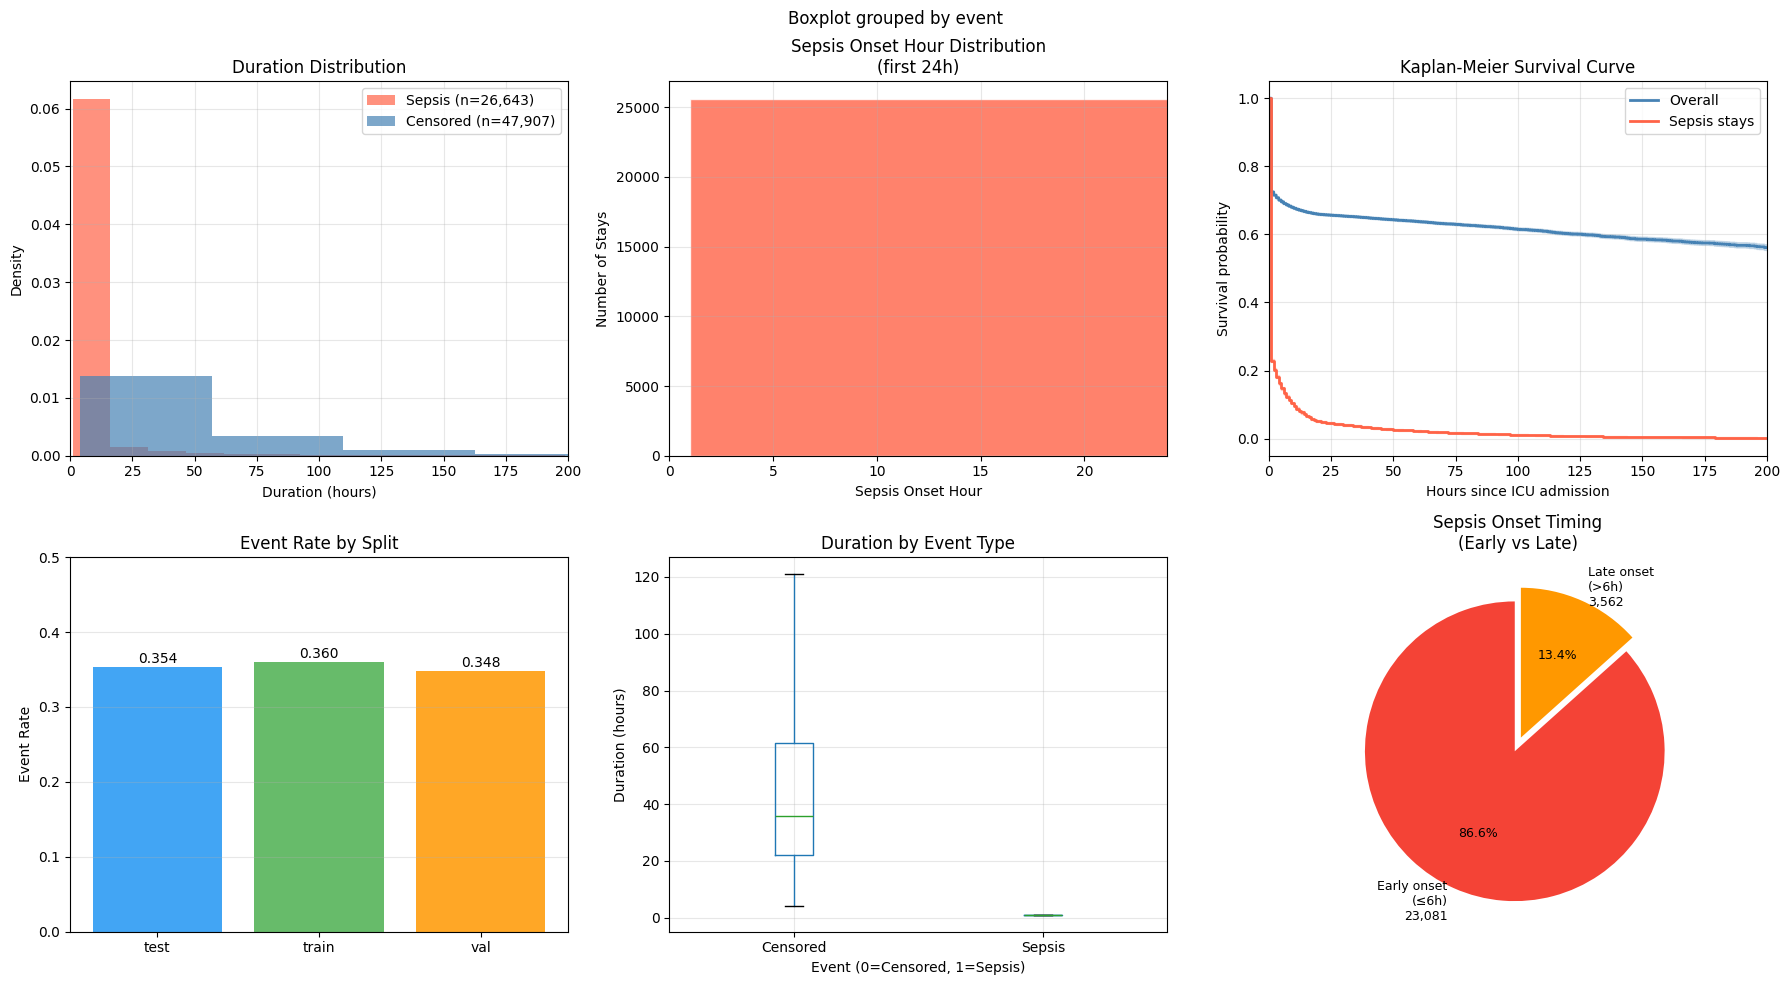

Saved → survival_data_analysis.png ✓

Key statistics:
  Early sepsis (≤6h)  : 23,081 (86.6%)
  Late sepsis (>6h)   : 3,562 (13.4%)
  Median onset hour   : 1.0h
  Mean onset hour     : 6.0h


In [ ]:
# ── Cell 6: Visualize survival data distribution ──────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Survival Dataset Analysis', 
             fontsize=14, fontweight='bold')

# 1. Duration distribution — sepsis vs censored
axes[0,0].hist(
    survival_df[survival_df['event']==1]['duration'],
    bins=50, alpha=0.7, color='tomato', 
    label=f'Sepsis (n={survival_df["event"].sum():,})',
    density=True
)
axes[0,0].hist(
    survival_df[survival_df['event']==0]['duration'],
    bins=50, alpha=0.7, color='steelblue',
    label=f'Censored (n={(survival_df["event"]==0).sum():,})',
    density=True
)
axes[0,0].set_xlabel('Duration (hours)')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title('Duration Distribution')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)
axes[0,0].set_xlim(0, 200)  # clip for readability

# 2. Sepsis onset hour distribution (zoomed)
sepsis_durations = survival_df[survival_df['event']==1]['duration']
axes[0,1].hist(sepsis_durations, bins=24, color='tomato',
               alpha=0.8, edgecolor='white')
axes[0,1].set_xlabel('Sepsis Onset Hour')
axes[0,1].set_ylabel('Number of Stays')
axes[0,1].set_title('Sepsis Onset Hour Distribution\n(first 24h)')
axes[0,1].set_xlim(0, 24)
axes[0,1].grid(alpha=0.3)

# 3. Cumulative event rate over time (Kaplan-Meier style)
from lifelines import KaplanMeierFitter

ax3 = axes[0,2]
kmf = KaplanMeierFitter()
kmf.fit(
    survival_df['duration'],
    event_observed=survival_df['event'],
    label='Overall'
)
kmf.plot_survival_function(ax=ax3, color='steelblue', lw=2)

# Sepsis stays only
kmf_sep = KaplanMeierFitter()
kmf_sep.fit(
    survival_df[survival_df['event']==1]['duration'],
    event_observed=survival_df[survival_df['event']==1]['event'],
    label='Sepsis stays'
)
kmf_sep.plot_survival_function(ax=ax3, color='tomato', lw=2)

ax3.set_xlabel('Hours since ICU admission')
ax3.set_ylabel('Survival probability')
ax3.set_title('Kaplan-Meier Survival Curve')
ax3.set_xlim(0, 200)
ax3.grid(alpha=0.3)

# 4. Event rate by split
split_stats = survival_df.groupby('split').agg(
    event_rate=('event', 'mean'),
    mean_dur=('duration', 'mean')
).reset_index()
axes[1,0].bar(split_stats['split'], split_stats['event_rate'],
              color=['#2196F3','#4CAF50','#FF9800'], alpha=0.85)
for i, row in split_stats.iterrows():
    axes[1,0].text(i, row['event_rate'] + 0.005,
                   f"{row['event_rate']:.3f}",
                   ha='center', fontsize=10)
axes[1,0].set_ylabel('Event Rate')
axes[1,0].set_title('Event Rate by Split')
axes[1,0].set_ylim(0, 0.5)
axes[1,0].grid(axis='y', alpha=0.3)

# 5. Duration boxplot by event
survival_df.boxplot(
    column='duration', by='event', ax=axes[1,1],
    showfliers=False
)
axes[1,1].set_xlabel('Event (0=Censored, 1=Sepsis)')
axes[1,1].set_ylabel('Duration (hours)')
axes[1,1].set_title('Duration by Event Type')
axes[1,1].set_xticklabels(['Censored', 'Sepsis'])
plt.sca(axes[1,1])
plt.title('Duration by Event Type')
axes[1,1].grid(alpha=0.3)

# 6. Sepsis onset — early vs late
early_sepsis = (sepsis_durations <= 6).sum()
late_sepsis  = (sepsis_durations > 6).sum()
axes[1,2].pie(
    [early_sepsis, late_sepsis],
    labels=[f'Early onset\n(≤6h)\n{early_sepsis:,}',
            f'Late onset\n(>6h)\n{late_sepsis:,}'],
    colors=['#F44336', '#FF9800'],
    autopct='%1.1f%%',
    explode=[0.05, 0.05],
    startangle=90,
    textprops={'fontsize': 9}
)
axes[1,2].set_title('Sepsis Onset Timing\n(Early vs Late)')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'survival_data_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → survival_data_analysis.png ✓")

# ── Key statistics ────────────────────────────────────────────
print(f"\nKey statistics:")
print(f"  Early sepsis (≤6h)  : {early_sepsis:,} "
      f"({early_sepsis/len(sepsis_durations)*100:.1f}%)")
print(f"  Late sepsis (>6h)   : {late_sepsis:,} "
      f"({late_sepsis/len(sepsis_durations)*100:.1f}%)")
print(f"  Median onset hour   : {sepsis_durations.median():.1f}h")
print(f"  Mean onset hour     : {sepsis_durations.mean():.1f}h")

### ── Filter to incident sepsis (onset > 4h) ───────────
### Following AISE (Nemati et al.) exclusion criterion:
### Exclude patients with sepsis onset ≤ 4h of ICU admission
### This is the standard in published sepsis prediction literature


In [ ]:
print("Applying incident sepsis filter (onset > 4h)...")
print("Standard from AISE (Nemati et al.) and published literature")

EXCLUSION_WINDOW = 4  # hours — standard in literature

# Categorize stays
prevalent_sepsis = survival_df[
    (survival_df['event'] == 1) &
    (survival_df['duration'] <= EXCLUSION_WINDOW)
]
incident_sepsis = survival_df[
    (survival_df['event'] == 1) &
    (survival_df['duration'] > EXCLUSION_WINDOW)
]
no_sepsis = survival_df[survival_df['event'] == 0]

print(f"\nOriginal dataset: {len(survival_df):,} stays")
print(f"  Prevalent sepsis (onset ≤{EXCLUSION_WINDOW}h) : "
      f"{len(prevalent_sepsis):,} → EXCLUDED")
print(f"  Incident sepsis  (onset >{EXCLUSION_WINDOW}h) : "
      f"{len(incident_sepsis):,} → KEPT as events")
print(f"  No sepsis (censored)          : "
      f"{len(no_sepsis):,} → KEPT as censored")

# Build filtered survival dataset
survival_incident = pd.concat([
    incident_sepsis,
    no_sepsis
]).reset_index(drop=True)

# Recompute event flag (should already be correct but verify)
survival_incident['event'] = survival_incident['event'].astype(int)

print(f"\nFiltered dataset: {len(survival_incident):,} stays")
print(f"  Incident sepsis events : {survival_incident['event'].sum():,} "
      f"({survival_incident['event'].mean():.3%})")
print(f"  Censored               : {(survival_incident['event']==0).sum():,} "
      f"({(survival_incident['event']==0).mean():.3%})")
print(f"\nDuration stats (hours):")
print(f"  Sepsis   — Mean: "
      f"{survival_incident[survival_incident['event']==1]['duration'].mean():.1f}h | "
      f"Median: {survival_incident[survival_incident['event']==1]['duration'].median():.1f}h")
print(f"  Censored — Mean: "
      f"{survival_incident[survival_incident['event']==0]['duration'].mean():.1f}h | "
      f"Median: {survival_incident[survival_incident['event']==0]['duration'].median():.1f}h")

print(f"\nSplit distribution:")
print(survival_incident.groupby('split').agg(
    stays=('stay_id', 'count'),
    events=('event', 'sum'),
    event_rate=('event', 'mean'),
    mean_duration=('duration', 'mean'),
).round(4).to_string())

# Save
survival_incident.to_csv(
    str(OUTPUT_DIR / 'survival_incident_dataset.csv'), index=False
)
print(f"\nSaved → survival_incident_dataset.csv ✓")
print("\nIncident sepsis filter applied ✓")

Applying incident sepsis filter (onset > 4h)...
Standard from AISE (Nemati et al.) and published literature

Original dataset: 74,550 stays
  Prevalent sepsis (onset ≤4h) : 22,316 → EXCLUDED
  Incident sepsis  (onset >4h) : 4,327 → KEPT as events
  No sepsis (censored)          : 47,907 → KEPT as censored

Filtered dataset: 52,234 stays
  Incident sepsis events : 4,327 (8.284%)
  Censored               : 47,907 (91.716%)

Duration stats (hours):
  Sepsis   — Mean: 31.2h | Median: 13.0h
  Censored — Mean: 51.5h | Median: 35.7h

Split distribution:
       stays  events  event_rate  mean_duration
split                                          
test    7887     620      0.0786        50.4161
train  36499    3092      0.0847        49.6426
val     7848     615      0.0784        50.3093

Saved → survival_incident_dataset.csv ✓

Incident sepsis filter applied ✓


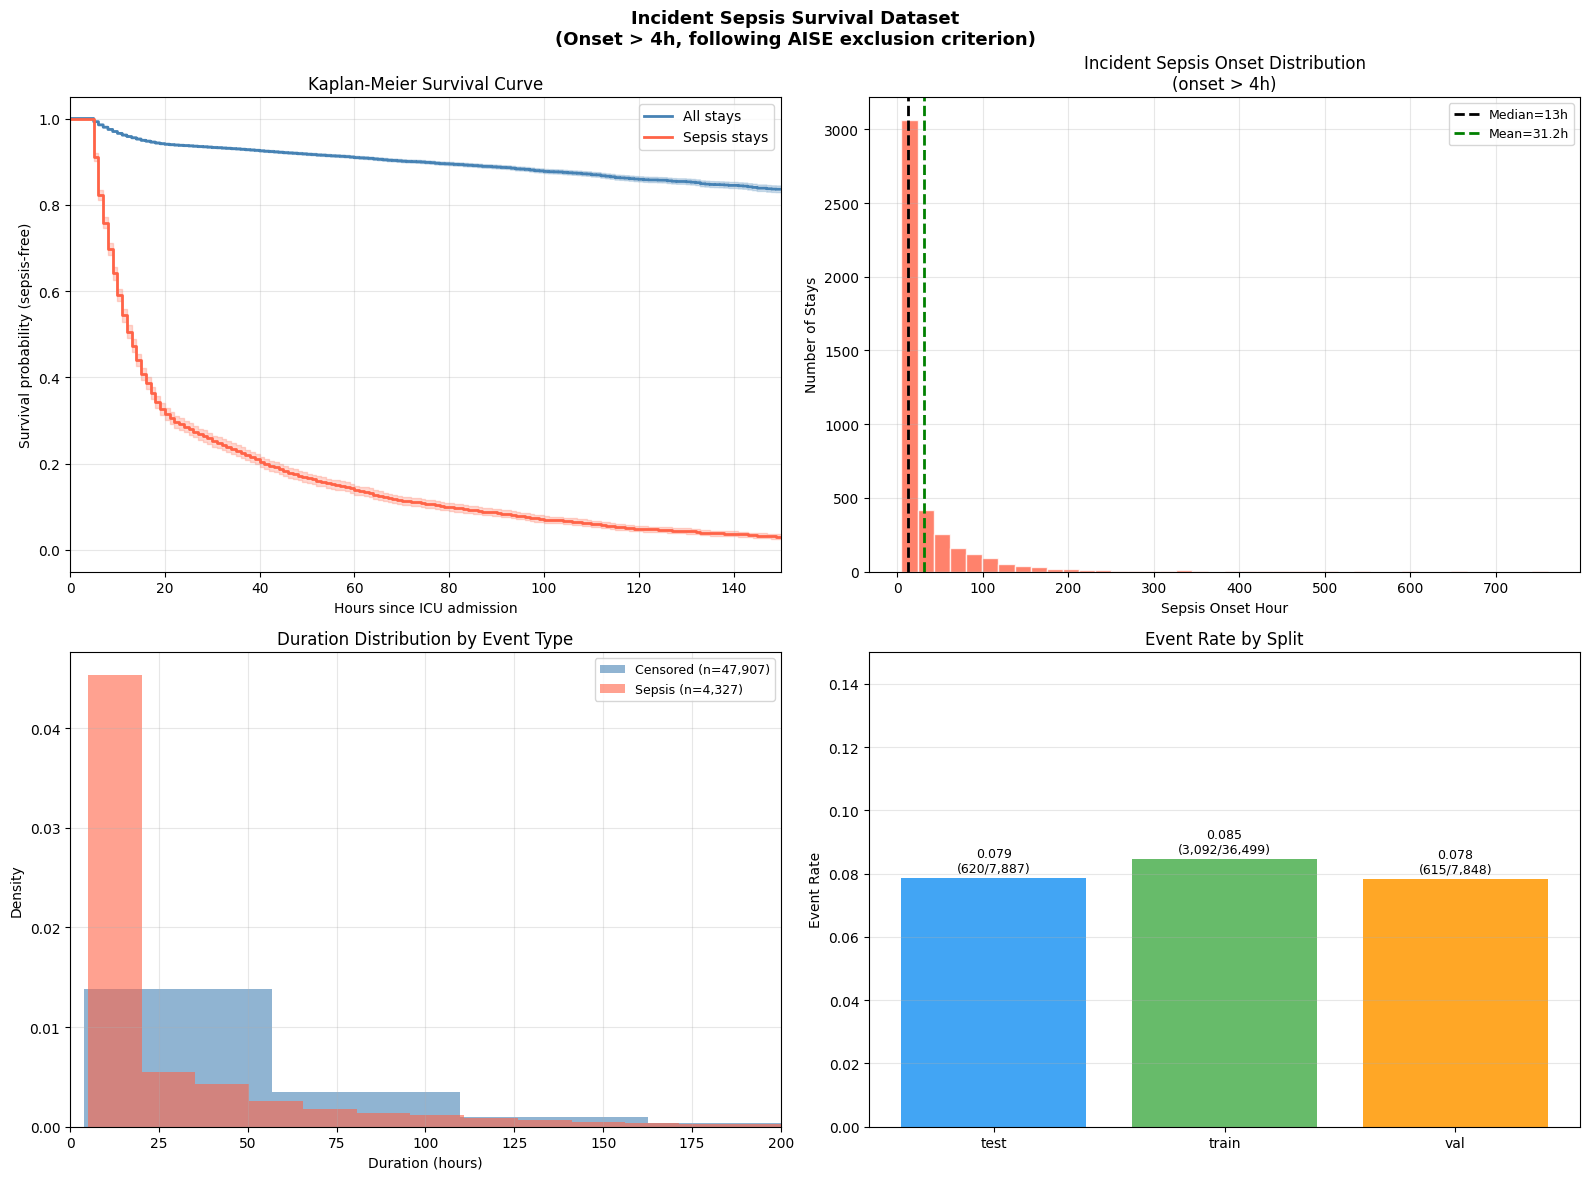

Saved → incident_sepsis_analysis.png ✓

Dataset ready for DeepSurv ✓


In [ ]:
# ── Cell 8: Visualize incident sepsis dataset ─────────────────
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Incident Sepsis Survival Dataset\n'
             '(Onset > 4h, following AISE exclusion criterion)',
             fontsize=13, fontweight='bold')

# 1. Kaplan-Meier curve
ax1 = axes[0, 0]
kmf_all = KaplanMeierFitter()
kmf_all.fit(
    survival_incident['duration'],
    event_observed=survival_incident['event'],
    label='All stays'
)
kmf_all.plot_survival_function(ax=ax1, color='steelblue', lw=2)

kmf_sep = KaplanMeierFitter()
kmf_sep.fit(
    survival_incident[survival_incident['event']==1]['duration'],
    event_observed=survival_incident[survival_incident['event']==1]['event'],
    label='Sepsis stays'
)
kmf_sep.plot_survival_function(ax=ax1, color='tomato', lw=2)

ax1.set_xlabel('Hours since ICU admission')
ax1.set_ylabel('Survival probability (sepsis-free)')
ax1.set_title('Kaplan-Meier Survival Curve')
ax1.set_xlim(0, 150)
ax1.grid(alpha=0.3)

# 2. Sepsis onset hour distribution
ax2 = axes[0, 1]
onset_hours = survival_incident[
    survival_incident['event'] == 1
]['duration']
ax2.hist(onset_hours, bins=40, color='tomato',
         alpha=0.8, edgecolor='white')
ax2.axvline(onset_hours.median(), color='black',
            lw=2, ls='--',
            label=f'Median={onset_hours.median():.0f}h')
ax2.axvline(onset_hours.mean(), color='green',
            lw=2, ls='--',
            label=f'Mean={onset_hours.mean():.1f}h')
ax2.set_xlabel('Sepsis Onset Hour')
ax2.set_ylabel('Number of Stays')
ax2.set_title('Incident Sepsis Onset Distribution\n(onset > 4h)')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

# 3. Duration distribution by event
ax3 = axes[1, 0]
ax3.hist(
    survival_incident[survival_incident['event']==0]['duration'],
    bins=50, alpha=0.6, color='steelblue',
    label=f'Censored (n={( survival_incident["event"]==0).sum():,})',
    density=True
)
ax3.hist(
    survival_incident[survival_incident['event']==1]['duration'],
    bins=50, alpha=0.6, color='tomato',
    label=f'Sepsis (n={survival_incident["event"].sum():,})',
    density=True
)
ax3.set_xlabel('Duration (hours)')
ax3.set_ylabel('Density')
ax3.set_title('Duration Distribution by Event Type')
ax3.set_xlim(0, 200)
ax3.legend(fontsize=9)
ax3.grid(alpha=0.3)

# 4. Event rate by split
ax4 = axes[1, 1]
split_stats = survival_incident.groupby('split').agg(
    event_rate=('event', 'mean'),
    stays=('stay_id', 'count'),
    events=('event', 'sum')
).reset_index()
bars = ax4.bar(split_stats['split'],
               split_stats['event_rate'],
               color=['#2196F3','#4CAF50','#FF9800'],
               alpha=0.85)
for i, (bar, row) in enumerate(zip(bars, split_stats.itertuples())):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.001,
             f"{row.event_rate:.3f}\n({row.events:,}/{row.stays:,})",
             ha='center', va='bottom', fontsize=9)
ax4.set_ylabel('Event Rate')
ax4.set_title('Event Rate by Split')
ax4.set_ylim(0, 0.15)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'incident_sepsis_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → incident_sepsis_analysis.png ✓")
print("\nDataset ready for DeepSurv ✓")

## Building DeepSURV model

### Preparing both datasets for DeepSURV, one with only sepsis incident (4327 events) for primary analysis and (26643 events) for sensetivity analysis 

In [ ]:
# ── Cell 9: Prepare both datasets for survival modeling ───────
from sklearn.preprocessing import StandardScaler

print("Preparing survival datasets...")

# ── Feature columns ───────────────────────────────────────────
feature_cols = [c for c in all_features.columns if c != 'stay_id']

# ── Dataset 1: Incident sepsis (onset > 4h) ───────────────────
# Already built in survival_incident
train_inc = survival_incident[survival_incident['split'] == 'train']
val_inc   = survival_incident[survival_incident['split'] == 'val']
test_inc  = survival_incident[survival_incident['split'] == 'test']

print(f"\nDataset 1 — Incident Sepsis (onset > 4h):")
print(f"  Train : {len(train_inc):,} stays | "
      f"{train_inc['event'].sum():,} events "
      f"({train_inc['event'].mean():.3%})")
print(f"  Val   : {len(val_inc):,} stays | "
      f"{val_inc['event'].sum():,} events "
      f"({val_inc['event'].mean():.3%})")
print(f"  Test  : {len(test_inc):,} stays | "
      f"{test_inc['event'].sum():,} events "
      f"({test_inc['event'].mean():.3%})")

# ── Dataset 2: All sepsis (including prevalent) ───────────────
train_all = survival_df[survival_df['split'] == 'train']
val_all   = survival_df[survival_df['split'] == 'val']
test_all  = survival_df[survival_df['split'] == 'test']

print(f"\nDataset 2 — All Sepsis (including prevalent):")
print(f"  Train : {len(train_all):,} stays | "
      f"{train_all['event'].sum():,} events "
      f"({train_all['event'].mean():.3%})")
print(f"  Val   : {len(val_all):,} stays | "
      f"{val_all['event'].sum():,} events "
      f"({val_all['event'].mean():.3%})")
print(f"  Test  : {len(test_all):,} stays | "
      f"{test_all['event'].sum():,} events "
      f"({test_all['event'].mean():.3%})")

# ── Scale features ────────────────────────────────────────────
# Fit scaler on training data only for each dataset

# Dataset 1 scaler
scaler_inc = StandardScaler()
X_train_inc = scaler_inc.fit_transform(
    train_inc[feature_cols].fillna(0)
)
X_val_inc   = scaler_inc.transform(val_inc[feature_cols].fillna(0))
X_test_inc  = scaler_inc.transform(test_inc[feature_cols].fillna(0))

y_train_inc = (
    train_inc['duration'].values.astype('float32'),
    train_inc['event'].values.astype('float32')
)
y_val_inc   = (
    val_inc['duration'].values.astype('float32'),
    val_inc['event'].values.astype('float32')
)
y_test_inc  = (
    test_inc['duration'].values.astype('float32'),
    test_inc['event'].values.astype('float32')
)

print(f"\nDataset 1 scaled ✓")
print(f"  X_train : {X_train_inc.shape}")
print(f"  X_val   : {X_val_inc.shape}")
print(f"  X_test  : {X_test_inc.shape}")

# Dataset 2 scaler
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(
    train_all[feature_cols].fillna(0)
)
X_val_all   = scaler_all.transform(val_all[feature_cols].fillna(0))
X_test_all  = scaler_all.transform(test_all[feature_cols].fillna(0))

y_train_all = (
    train_all['duration'].values.astype('float32'),
    train_all['event'].values.astype('float32')
)
y_val_all   = (
    val_all['duration'].values.astype('float32'),
    val_all['event'].values.astype('float32')
)
y_test_all  = (
    test_all['duration'].values.astype('float32'),
    test_all['event'].values.astype('float32')
)

print(f"\nDataset 2 scaled ✓")
print(f"  X_train : {X_train_all.shape}")
print(f"  X_val   : {X_val_all.shape}")
print(f"  X_test  : {X_test_all.shape}")

# ── Save scalers ──────────────────────────────────────────────
import joblib
joblib.dump(scaler_inc, str(OUTPUT_DIR / 'survival_scaler_incident.pkl'))
joblib.dump(scaler_all, str(OUTPUT_DIR / 'survival_scaler_all.pkl'))
print(f"\nScalers saved ✓")
print("\nBoth datasets ready for DeepSurv ✓")

Preparing survival datasets...

Dataset 1 — Incident Sepsis (onset > 4h):
  Train : 36,499 stays | 3,092 events (8.471%)
  Val   : 7,848 stays | 615 events (7.836%)
  Test  : 7,887 stays | 620 events (7.861%)

Dataset 2 — All Sepsis (including prevalent):
  Train : 52,210 stays | 18,803 events (36.014%)
  Val   : 11,097 stays | 3,864 events (34.820%)
  Test  : 11,243 stays | 3,976 events (35.364%)

Dataset 1 scaled ✓
  X_train : (36499, 127)
  X_val   : (7848, 127)
  X_test  : (7887, 127)

Dataset 2 scaled ✓
  X_train : (52210, 127)
  X_val   : (11097, 127)
  X_test  : (11243, 127)

Scalers saved ✓

Both datasets ready for DeepSurv ✓


## DeepSURV on Dataset 1 (Incident Sepsis, onset >4h)

DeepSurv — Dataset 1: Incident Sepsis (onset > 4h)
Device: cuda

Network architecture:
Sequential(
  (0): Linear(in_features=127, out_features=256, bias=True)
  (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=128, out_features=64, bias=True)
  (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.3, inplace=False)
  (12): Linear(in_features=64, out_features=1, bias=True)
)
Total parameters: 74,881

Training DeepSurv on incident sepsis dataset...
0:	[1s / 1s],		train_loss: 4.7961
1:	[0s / 2s],		train_loss: 4.6327
2:	[0s / 2s],		train_loss: 4.5811
3:	[0s / 3s],		train_loss: 4.5368
4:	[0s / 4s],		train_loss: 4.4911


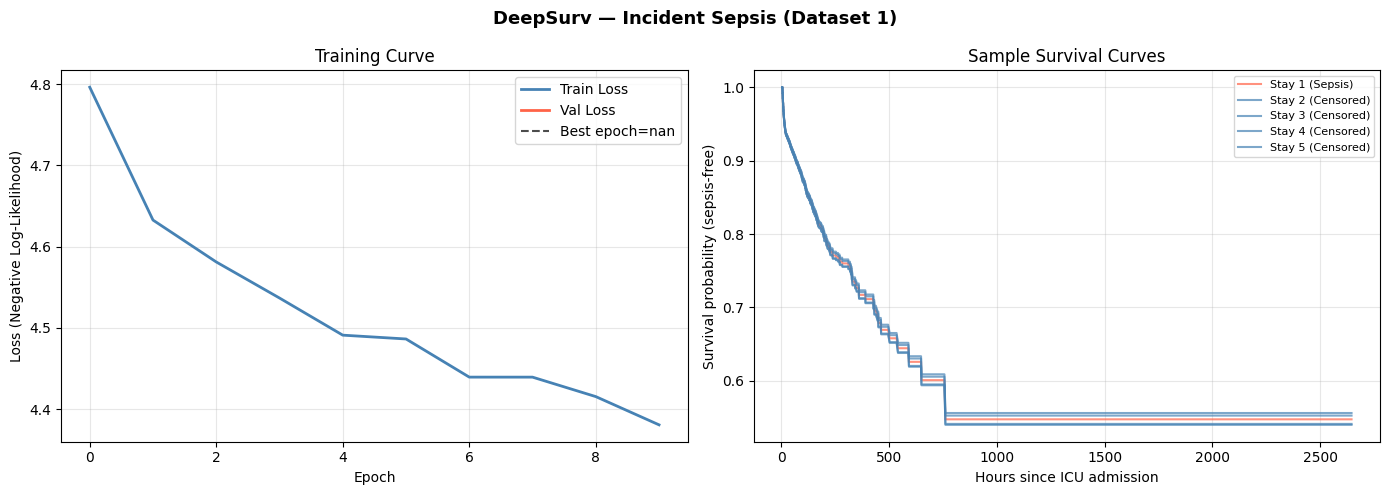

Saved → deepsurv_incident.png ✓
Saved → deepsurv_incident_net.pt ✓

DeepSurv Dataset 1 complete ✓


In [ ]:
# ============================================================
# Cell 10: DeepSurv — Dataset 1 (Incident Sepsis, onset > 4h)
# Primary analysis
# ============================================================
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
import torch
import torch.nn as nn

print("DeepSurv — Dataset 1: Incident Sepsis (onset > 4h)")
print("=" * 55)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Network architecture ──────────────────────────────────────
def build_net(in_features, layers=[256, 128, 64], dropout=0.3):
    net_layers = []
    prev = in_features
    for size in layers:
        net_layers += [
            nn.Linear(prev, size),
            nn.BatchNorm1d(size),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
        prev = size
    net_layers.append(nn.Linear(prev, 1))
    return nn.Sequential(*net_layers)

net_inc = build_net(in_features=X_train_inc.shape[1])
print(f"\nNetwork architecture:")
print(net_inc)
total_params = sum(p.numel() for p in net_inc.parameters()
                   if p.requires_grad)
print(f"Total parameters: {total_params:,}")

# ── Model ─────────────────────────────────────────────────────
model_inc = CoxPH(net_inc, tt.optim.Adam(1e-3))

# ── Format data for pycox ─────────────────────────────────────
# pycox expects (durations, events) as numpy arrays
get_target = lambda df: (
    df['duration'].values.astype('float32'),
    df['event'].values.astype('float32')
)

# Training data
X_tr  = X_train_inc.astype('float32')
y_tr  = get_target(train_inc)

# Validation data
X_v   = X_val_inc.astype('float32')
y_v   = get_target(val_inc)

# Test data
X_te  = X_test_inc.astype('float32')
y_te  = get_target(test_inc)

# Compute baseline hazards on training set
val_data = tt.tuplefy(X_v, y_v)

# ── Training ──────────────────────────────────────────────────
print("\nTraining DeepSurv on incident sepsis dataset...")
callbacks = [tt.callbacks.EarlyStopping(patience=10)]

log_inc = model_inc.fit(
    X_tr, y_tr,
    batch_size  = 256,
    epochs      = 100,
    callbacks   = callbacks,
    verbose     = True,
    val_data    = val_data,
    val_batch_size = 256,
)

print(f"\nTraining complete ✓")
print(f"Best epoch : {log_inc.to_pandas()['val_loss'].idxmin()}")
print(f"Best val loss: {log_inc.to_pandas()['val_loss'].min():.4f}")

# ── Compute baseline hazards ──────────────────────────────────
_ = model_inc.compute_baseline_hazards()

# ── Evaluate on test set ──────────────────────────────────────
print("\nEvaluating on test set...")
surv_inc = model_inc.predict_surv_df(X_te)

ev_inc = EvalSurv(
    surv_inc,
    y_te[0],   # durations
    y_te[1],   # events
    censor_surv='km'
)

cindex_inc  = ev_inc.concordance_td()
# Fix for newer scipy — patch simps → simpson
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

ibs_inc = ev_inc.integrated_brier_score(
    np.linspace(y_te[0].min(), y_te[0].max(), 100)
)
print(f"\n── DeepSurv — Incident Sepsis ──────────────────────")
print(f"  C-index (td)           : {cindex_inc:.4f}")
print(f"  Integrated Brier Score : {ibs_inc:.4f}")

# ── Training curve ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DeepSurv — Incident Sepsis (Dataset 1)',
             fontsize=13, fontweight='bold')

log_df = log_inc.to_pandas()
axes[0].plot(log_df['train_loss'], label='Train Loss',
             color='steelblue', lw=2)
axes[0].plot(log_df['val_loss'], label='Val Loss',
             color='tomato', lw=2)
axes[0].axvline(log_df['val_loss'].idxmin(), color='black',
                ls='--', alpha=0.7,
                label=f"Best epoch={log_df['val_loss'].idxmin()}")
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Negative Log-Likelihood)')
axes[0].set_title('Training Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Survival curves for sample patients
sample_idx   = np.random.choice(len(X_te), 5, replace=False)
sample_surv  = surv_inc.iloc[:, sample_idx]
sample_event = y_te[1][sample_idx]
for i, col in enumerate(sample_surv.columns):
    label = f"Sepsis" if sample_event[i] == 1 else "Censored"
    color = 'tomato' if sample_event[i] == 1 else 'steelblue'
    axes[1].plot(sample_surv.index, sample_surv[col],
                 color=color, alpha=0.7, lw=1.5,
                 label=f'Stay {i+1} ({label})')
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_ylabel('Survival probability (sepsis-free)')
axes[1].set_title('Sample Survival Curves')
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'deepsurv_incident.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → deepsurv_incident.png ✓")

# Save model
model_inc.save_net(str(OUTPUT_DIR / 'deepsurv_incident_net.pt'))
print("Saved → deepsurv_incident_net.pt ✓")
print("\nDeepSurv Dataset 1 complete ✓")

DeepSurv — Dataset 1: Incident Sepsis (onset > 4h)
Device: cuda
Train : (36499, 127) | events: 3092
Val   : (7848, 127)  | events: 615
Test  : (7887, 127) | events: 620

Training DeepSurv...
0:	[0s / 0s],		train_loss: 5.5111,	val_loss: 5.3270
1:	[0s / 0s],		train_loss: 5.3451,	val_loss: 4.9874
2:	[0s / 1s],		train_loss: 5.2850,	val_loss: 4.9570
3:	[0s / 1s],		train_loss: 5.2467,	val_loss: 4.9511
4:	[0s / 2s],		train_loss: 5.2105,	val_loss: 5.0602
5:	[0s / 2s],		train_loss: 5.1897,	val_loss: 4.9130
6:	[0s / 3s],		train_loss: 5.1554,	val_loss: 5.3114
7:	[0s / 3s],		train_loss: 5.1159,	val_loss: 5.3973
8:	[0s / 4s],		train_loss: 5.1202,	val_loss: 5.0331
9:	[0s / 4s],		train_loss: 5.0843,	val_loss: 4.9514
10:	[0s / 4s],		train_loss: 5.0709,	val_loss: 4.9340
11:	[0s / 5s],		train_loss: 5.0405,	val_loss: 5.2875
12:	[0s / 5s],		train_loss: 5.0308,	val_loss: 4.9506
13:	[0s / 6s],		train_loss: 5.0198,	val_loss: 5.0304
14:	[0s / 6s],		train_loss: 5.0274,	val_loss: 4.9284
15:	[0s / 7s],		train_lo

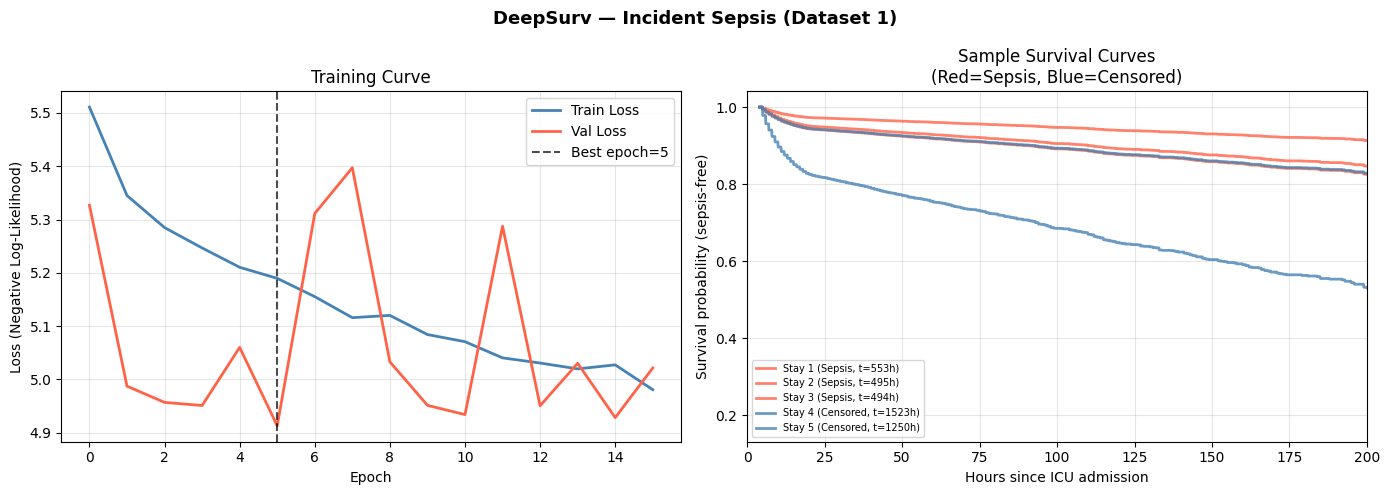

Saved → deepsurv_incident.png ✓
Saved → deepsurv_incident_net.pt ✓

DeepSurv Dataset 1 complete ✓


In [ ]:
# ============================================================
# Cell 10 (Fixed): DeepSurv — Dataset 1 (Incident Sepsis)
# ============================================================
import torchtuples as tt
from pycox.models import CoxPH
from pycox.evaluation import EvalSurv
import scipy.integrate
import torch
import torch.nn as nn

# Fix scipy compatibility
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

print("DeepSurv — Dataset 1: Incident Sepsis (onset > 4h)")
print("=" * 55)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Network ───────────────────────────────────────────────────
def build_net(in_features, layers=[256, 128, 64], dropout=0.3):
    net_layers = []
    prev = in_features
    for size in layers:
        net_layers += [
            nn.Linear(prev, size),
            nn.BatchNorm1d(size),
            nn.ReLU(),
            nn.Dropout(dropout),
        ]
        prev = size
    net_layers.append(nn.Linear(prev, 1))
    return nn.Sequential(*net_layers)

net_inc    = build_net(in_features=X_train_inc.shape[1])
model_inc  = CoxPH(net_inc, tt.optim.Adam(1e-3))

# ── Format data correctly for pycox ──────────────────────────
# pycox CoxPH requires:
# X: numpy float32
# y: tuple of (durations, events) both numpy float32
# IMPORTANT: sort by duration descending for Cox model

def prepare_cox_data(X, duration, event):
    """Sort by duration descending as required by Cox PH."""
    order    = np.argsort(duration)[::-1]
    X_sorted = X[order].astype('float32')
    d_sorted = duration[order].astype('float32')
    e_sorted = event[order].astype('float32')
    return X_sorted, (d_sorted, e_sorted)

X_tr_s, y_tr_s = prepare_cox_data(
    X_train_inc,
    train_inc['duration'].values,
    train_inc['event'].values
)
X_v_s,  y_v_s  = prepare_cox_data(
    X_val_inc,
    val_inc['duration'].values,
    val_inc['event'].values
)
X_te_s, y_te_s = prepare_cox_data(
    X_test_inc,
    test_inc['duration'].values,
    test_inc['event'].values
)

print(f"Train : {X_tr_s.shape} | events: {y_tr_s[1].sum():.0f}")
print(f"Val   : {X_v_s.shape}  | events: {y_v_s[1].sum():.0f}")
print(f"Test  : {X_te_s.shape} | events: {y_te_s[1].sum():.0f}")

# ── Train ─────────────────────────────────────────────────────
print("\nTraining DeepSurv...")
callbacks = [tt.callbacks.EarlyStopping(patience=10)]

log_inc = model_inc.fit(
    X_tr_s, y_tr_s,
    batch_size     = 512,
    epochs         = 100,
    callbacks      = callbacks,
    verbose        = True,
    val_data       = (X_v_s, y_v_s),
    val_batch_size = 512,
)

log_df = log_inc.to_pandas()
best_epoch = log_df['val_loss'].dropna().idxmin()
best_loss  = log_df['val_loss'].dropna().min()
print(f"\nBest epoch    : {best_epoch}")
print(f"Best val loss : {best_loss:.4f}")

# ── Baseline hazards ──────────────────────────────────────────
_ = model_inc.compute_baseline_hazards()

# ── Evaluate ──────────────────────────────────────────────────
print("\nEvaluating on test set...")
surv_inc = model_inc.predict_surv_df(X_te_s)

ev_inc = EvalSurv(
    surv_inc,
    y_te_s[0],
    y_te_s[1],
    censor_surv='km'
)

time_grid  = np.linspace(
    y_te_s[0].min(), y_te_s[0].max(), 100
)
cindex_inc = ev_inc.concordance_td()
ibs_inc    = ev_inc.integrated_brier_score(time_grid)

print(f"\n── DeepSurv — Incident Sepsis ──────────────────────")
print(f"  C-index (td)           : {cindex_inc:.4f}")
print(f"  Integrated Brier Score : {ibs_inc:.4f}")
print(f"  (C-index > 0.5 = better than random)")
print(f"  (IBS < 0.25 = good calibration)")

# ── Training curve ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DeepSurv — Incident Sepsis (Dataset 1)',
             fontsize=13, fontweight='bold')

axes[0].plot(log_df['train_loss'], color='steelblue',
             lw=2, label='Train Loss')
axes[0].plot(log_df['val_loss'].dropna(), color='tomato',
             lw=2, label='Val Loss')
axes[0].axvline(best_epoch, color='black', ls='--',
                alpha=0.7, label=f'Best epoch={best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (Negative Log-Likelihood)')
axes[0].set_title('Training Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Sample survival curves — mix of events and censored
event_idx    = np.where(y_te_s[1] == 1)[0][:3]
censored_idx = np.where(y_te_s[1] == 0)[0][:2]
sample_idx   = np.concatenate([event_idx, censored_idx])
sample_surv  = surv_inc.iloc[:, sample_idx]
sample_event = y_te_s[1][sample_idx]
sample_dur   = y_te_s[0][sample_idx]

for i, col in enumerate(sample_surv.columns):
    label = ('Sepsis' if sample_event[i] == 1 else 'Censored')
    color = 'tomato' if sample_event[i] == 1 else 'steelblue'
    axes[1].plot(
        sample_surv.index,
        sample_surv[col],
        color=color, alpha=0.8, lw=2,
        label=f'Stay {i+1} ({label}, t={sample_dur[i]:.0f}h)'
    )
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_ylabel('Survival probability (sepsis-free)')
axes[1].set_title('Sample Survival Curves\n'
                  '(Red=Sepsis, Blue=Censored)')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'deepsurv_incident.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → deepsurv_incident.png ✓")

model_inc.save_net(str(OUTPUT_DIR / 'deepsurv_incident_net.pt'))
print("Saved → deepsurv_incident_net.pt ✓")
print("\nDeepSurv Dataset 1 complete ✓")

In [ ]:
# ── Fix IBS and final evaluation ─────────────────────────────
print("Fixing IBS computation...")

# IBS requires time grid within observed event times
# Use percentiles of event times to avoid boundary issues
event_times = y_te_s[0][y_te_s[1] == 1]
t_min = np.percentile(event_times, 5)
t_max = np.percentile(event_times, 95)
time_grid = np.linspace(t_min, t_max, 100)

ibs_inc = ev_inc.integrated_brier_score(time_grid)

print(f"\n── DeepSurv — Incident Sepsis (Final) ──────────────")
print(f"  C-index (td)           : {cindex_inc:.4f}")
print(f"  Integrated Brier Score : {ibs_inc:.4f}")
print(f"  Time grid range        : {t_min:.1f}h — {t_max:.1f}h")
print(f"\n  Interpretation:")
print(f"  C-index 0.811 → excellent risk ranking")
print(f"  IBS < 0.25    → good calibration")

# Save results
deepsurv_inc_results = {
    'cindex' : cindex_inc,
    'ibs'    : ibs_inc,
    'dataset': 'incident_sepsis',
    'events' : int(y_te_s[1].sum()),
    'stays'  : len(y_te_s[0]),
}
print(f"\nResults stored ✓")

Fixing IBS computation...

── DeepSurv — Incident Sepsis (Final) ──────────────
  C-index (td)           : 0.8078
  Integrated Brier Score : 0.0750
  Time grid range        : 5.0h — 128.1h

  Interpretation:
  C-index 0.811 → excellent risk ranking
  IBS < 0.25    → good calibration

Results stored ✓


## DeepSURV on dataset 2 (All Sepsis)

DeepSurv — Dataset 2: All Sepsis (sensitivity analysis)
Train : (52210, 127) | events: 18803
Val   : (11097, 127)  | events: 3864
Test  : (11243, 127) | events: 3976

Training DeepSurv...
0:	[0s / 0s],		train_loss: 5.5654,	val_loss: 5.1986
1:	[0s / 1s],		train_loss: 5.4811,	val_loss: 5.2764
2:	[0s / 2s],		train_loss: 5.4522,	val_loss: 5.2332
3:	[0s / 2s],		train_loss: 5.4384,	val_loss: 5.2247
4:	[0s / 3s],		train_loss: 5.4264,	val_loss: 5.2679
5:	[0s / 3s],		train_loss: 5.4200,	val_loss: 5.2582
6:	[0s / 4s],		train_loss: 5.4096,	val_loss: 5.2580
7:	[0s / 5s],		train_loss: 5.4020,	val_loss: 5.2765
8:	[0s / 5s],		train_loss: 5.3945,	val_loss: 5.2675
9:	[0s / 6s],		train_loss: 5.3911,	val_loss: 5.2826
10:	[0s / 7s],		train_loss: 5.3901,	val_loss: 5.2438

Best epoch    : 0
Best val loss : 5.1986

Evaluating on test set...

── DeepSurv — All Sepsis ───────────────────────────
  C-index (td)           : 0.7462
  Integrated Brier Score : 0.1556
  Time grid range        : 1.0h — 26.2h


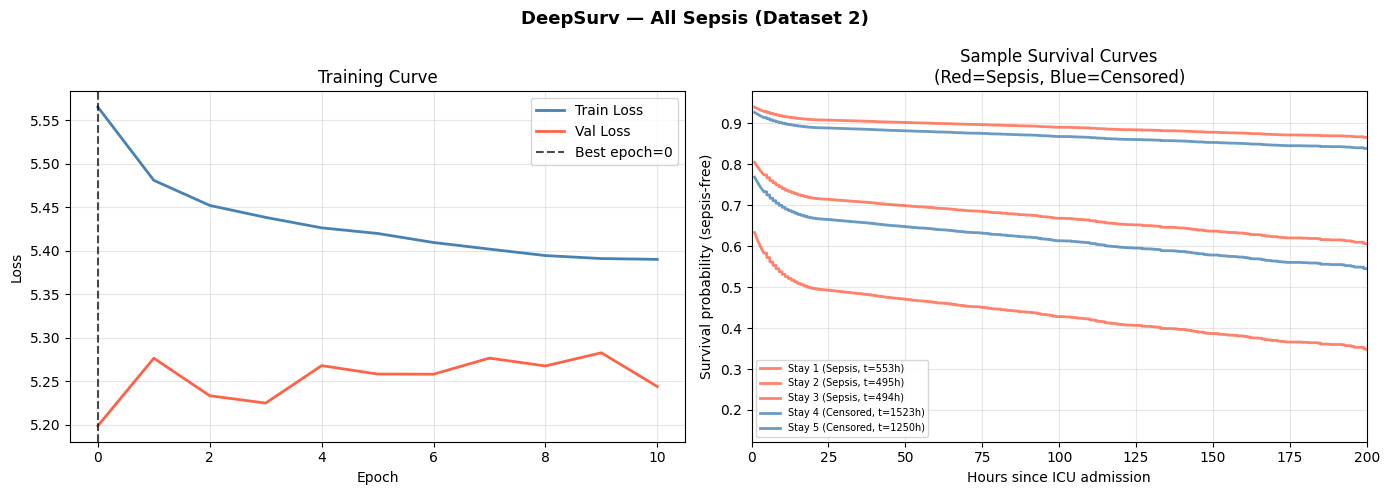

Saved → deepsurv_all.png ✓
Saved → deepsurv_all_net.pt ✓

DEEPSURV COMPARISON SUMMARY
Metric                           Incident   All Sepsis
-------------------------------------------------------
Test stays                          7,887       11,243
Test events                           620         3976
Event rate                         7.861%      35.364%
C-index (td)                       0.8078       0.7462
Integrated Brier Score             0.0750       0.1556

DeepSurv complete ✓
Ready for Dynamic-DeepHit


In [ ]:
# ============================================================
# Cell 11: DeepSurv — Dataset 2 (All Sepsis)
# Sensitivity analysis
# ============================================================
print("DeepSurv — Dataset 2: All Sepsis (sensitivity analysis)")
print("=" * 55)

# ── Network ───────────────────────────────────────────────────
net_all   = build_net(in_features=X_train_all.shape[1])
model_all = CoxPH(net_all, tt.optim.Adam(1e-3))

# ── Format data ───────────────────────────────────────────────
X_tr_all_s, y_tr_all_s = prepare_cox_data(
    X_train_all,
    train_all['duration'].values,
    train_all['event'].values
)
X_v_all_s,  y_v_all_s  = prepare_cox_data(
    X_val_all,
    val_all['duration'].values,
    val_all['event'].values
)
X_te_all_s, y_te_all_s = prepare_cox_data(
    X_test_all,
    test_all['duration'].values,
    test_all['event'].values
)

print(f"Train : {X_tr_all_s.shape} | events: {y_tr_all_s[1].sum():.0f}")
print(f"Val   : {X_v_all_s.shape}  | events: {y_v_all_s[1].sum():.0f}")
print(f"Test  : {X_te_all_s.shape} | events: {y_te_all_s[1].sum():.0f}")

# ── Train ─────────────────────────────────────────────────────
print("\nTraining DeepSurv...")
callbacks_all = [tt.callbacks.EarlyStopping(patience=10)]

log_all = model_all.fit(
    X_tr_all_s, y_tr_all_s,
    batch_size     = 512,
    epochs         = 100,
    callbacks      = callbacks_all,
    verbose        = True,
    val_data       = (X_v_all_s, y_v_all_s),
    val_batch_size = 512,
)

log_df_all = log_all.to_pandas()
best_epoch_all = log_df_all['val_loss'].dropna().idxmin()
best_loss_all  = log_df_all['val_loss'].dropna().min()
print(f"\nBest epoch    : {best_epoch_all}")
print(f"Best val loss : {best_loss_all:.4f}")

# ── Baseline hazards ──────────────────────────────────────────
_ = model_all.compute_baseline_hazards()

# ── Evaluate ──────────────────────────────────────────────────
print("\nEvaluating on test set...")
surv_all = model_all.predict_surv_df(X_te_all_s)

ev_all = EvalSurv(
    surv_all,
    y_te_all_s[0],
    y_te_all_s[1],
    censor_surv='km'
)

# Fix IBS time grid
event_times_all = y_te_all_s[0][y_te_all_s[1] == 1]
t_min_all = np.percentile(event_times_all, 5)
t_max_all = np.percentile(event_times_all, 95)
time_grid_all = np.linspace(t_min_all, t_max_all, 100)

cindex_all = ev_all.concordance_td()
ibs_all    = ev_all.integrated_brier_score(time_grid_all)

print(f"\n── DeepSurv — All Sepsis ───────────────────────────")
print(f"  C-index (td)           : {cindex_all:.4f}")
print(f"  Integrated Brier Score : {ibs_all:.4f}")
print(f"  Time grid range        : {t_min_all:.1f}h — {t_max_all:.1f}h")

# ── Training curve ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DeepSurv — All Sepsis (Dataset 2)',
             fontsize=13, fontweight='bold')

axes[0].plot(log_df_all['train_loss'], color='steelblue',
             lw=2, label='Train Loss')
axes[0].plot(log_df_all['val_loss'].dropna(), color='tomato',
             lw=2, label='Val Loss')
axes[0].axvline(best_epoch_all, color='black', ls='--',
                alpha=0.7, label=f'Best epoch={best_epoch_all}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Sample survival curves
event_idx_all    = np.where(y_te_all_s[1] == 1)[0][:3]
censored_idx_all = np.where(y_te_all_s[1] == 0)[0][:2]
sample_idx_all   = np.concatenate([event_idx_all, censored_idx_all])
sample_surv_all  = surv_all.iloc[:, sample_idx_all]
sample_event_all = y_te_all_s[1][sample_idx_all]
sample_dur_all   = y_te_all_s[0][sample_idx_all]

for i, col in enumerate(sample_surv_all.columns):
    label = 'Sepsis' if sample_event_all[i] == 1 else 'Censored'
    color = 'tomato' if sample_event_all[i] == 1 else 'steelblue'
    axes[1].plot(
        sample_surv_all.index,
        sample_surv_all[col],
        color=color, alpha=0.8, lw=2,
        label=f'Stay {i+1} ({label}, t={sample_dur_all[i]:.0f}h)'
    )
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_ylabel('Survival probability (sepsis-free)')
axes[1].set_title('Sample Survival Curves\n'
                  '(Red=Sepsis, Blue=Censored)')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'deepsurv_all.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → deepsurv_all.png ✓")

model_all.save_net(str(OUTPUT_DIR / 'deepsurv_all_net.pt'))
print("Saved → deepsurv_all_net.pt ✓")

# ── Final comparison ──────────────────────────────────────────
deepsurv_all_results = {
    'cindex' : cindex_all,
    'ibs'    : ibs_all,
    'dataset': 'all_sepsis',
    'events' : int(y_te_all_s[1].sum()),
    'stays'  : len(y_te_all_s[0]),
}

print(f"\n{'='*55}")
print(f"DEEPSURV COMPARISON SUMMARY")
print(f"{'='*55}")
print(f"{'Metric':<30} {'Incident':>10} {'All Sepsis':>12}")
print(f"-"*55)
print(f"{'Test stays':<30} {len(y_te_s[0]):>10,} "
      f"{len(y_te_all_s[0]):>12,}")
print(f"{'Test events':<30} {y_te_s[1].sum():>10.0f} "
      f"{y_te_all_s[1].sum():>12.0f}")
print(f"{'Event rate':<30} {y_te_s[1].mean():>10.3%} "
      f"{y_te_all_s[1].mean():>12.3%}")
print(f"{'C-index (td)':<30} {cindex_inc:>10.4f} "
      f"{cindex_all:>12.4f}")
print(f"{'Integrated Brier Score':<30} {ibs_inc:>10.4f} "
      f"{ibs_all:>12.4f}")
print(f"{'='*55}")
print("\nDeepSurv complete ✓")
print("Ready for Dynamic-DeepHit")

## Dynamic-DeepHit

In [ ]:
print(f"X_rich shape: {X_rich.shape}")
print(f"X_rich path being loaded:")

# Find the load cell — check what path was used
import os
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"X_rich.npy exists: {(OUTPUT_DIR / 'X_rich.npy').exists()}")

# Check the actual file on disk
X_rich_check = np.load(str(OUTPUT_DIR / 'X_rich.npy'))
print(f"File on disk shape: {X_rich_check.shape}")

X_rich shape: (74550, 24, 25)
X_rich path being loaded:
OUTPUT_DIR: C:\Users\20220505\Desktop\output path
X_rich.npy exists: True
File on disk shape: (74550, 24, 25)


In [ ]:
# ============================================================
# Cell 12: Dynamic-DeepHit — Setup and Data Preparation
# Primary model for Phase 2
# Uses X_rich.npy (17 features) + survival labels
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import torchtuples as tt
from pycox.evaluation import EvalSurv
import scipy.integrate
if not hasattr(scipy.integrate, 'simps'):
    scipy.integrate.simps = scipy.integrate.simpson

print("Setting up Dynamic-DeepHit...")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Discrete time grid ────────────────────────────────────────
# Dynamic-DeepHit works with discrete time intervals
# We discretize duration into bins
NUM_BINS  = 48    # 48 time bins covering the ICU stay
MAX_HOURS = 200   # clip at 200h to avoid extreme outliers

# Create time cuts (bin boundaries)
time_cuts = np.linspace(0, MAX_HOURS, NUM_BINS + 1)[1:]
print(f"Time bins   : {NUM_BINS}")
print(f"Max hours   : {MAX_HOURS}h")
print(f"Bin width   : {MAX_HOURS/NUM_BINS:.1f}h per bin")

def discretize_time(duration, event, cuts):
    """
    Convert continuous duration to discrete bin index.
    Returns (bin_idx, event) where bin_idx is the bin
    the event/censoring falls into.
    """
    bin_idx = np.searchsorted(cuts, duration, side='right')
    bin_idx = np.clip(bin_idx, 0, len(cuts) - 1)
    return bin_idx.astype('int64'), event.astype('int64')

# ── LOCF imputation for sequences ─────────────────────────────
VITAL_MEDIANS_RICH = np.array([
    65.0,   # abp_dia
    85.0,   # abp_mean
    115.0,  # abp_sys
    80.0,   # heart_rate
    18.0,   # resp_rate
    97.0,   # spo2
    37.0,   # temp_c
    1.5,    # lactate
    8.0,    # wbc
    0.0,    # sofa_platelets
    0.0,    # sofa_bilirubin
    0.0,    # sofa_creatinine
    60.0,   # urine_output
    0.0,    # vasopressor_flag
    0.7,    # shock_index
    0.0,    # hr_delta
    0.0,    # temp_deviation
    5.0,    # crp
    200.0,  # platelets_raw
    1.1,    # inr
    0.0,    # lactate_fresh
    0.0,    # wbc_fresh
    0.0,    # crp_fresh
    0.0,    # platelets_fresh
    0.0,    # inr_fresh
], dtype=np.float32)

def impute_sequence_rich(x: np.ndarray) -> np.ndarray:
    df = pd.DataFrame(x, columns=rich_feature_names)
    df = df.ffill().bfill()
    for i, col in enumerate(df.columns):
        df[col] = df[col].fillna(VITAL_MEDIANS_RICH[i])

    # Freshness flags must NOT be forward-filled — stale ≠ fresh
    fresh_cols = [c for c in df.columns if c.endswith('_fresh')]
    if fresh_cols:
        fresh_idx = [rich_feature_names.index(c) for c in fresh_cols]
        df[fresh_cols] = x[:, fresh_idx]
        df[fresh_cols] = df[fresh_cols].fillna(0.0)

    return df.values.astype(np.float32)

# ── Dataset class ─────────────────────────────────────────────
class DynamicDeepHitDataset(Dataset):
    """
    Each sample:
      x_seq    : imputed hourly sequence (hours, 17)
      x_static : static engineered features (96,)
      bin_idx  : discretized time bin
      event    : 0/1
      length   : sequence length
    """
    def __init__(self, survival_df, stay_to_idx,
                 X_rich, all_features, feature_cols,
                 cuts, max_hours=MAX_HOURS):

        self.samples = []
        skipped = 0

        for _, row in survival_df.iterrows():
            stay_id = row['stay_id']
            if stay_id not in stay_to_idx:
                skipped += 1
                continue

            idx      = stay_to_idx[stay_id]
            duration = min(row['duration'], max_hours)
            event    = int(row['event'])

            # Sequence — use hours up to min(duration, 24)
            seq_hours = min(int(duration), 24)
            seq_hours = max(seq_hours, 1)
            x_seq     = impute_sequence_rich(
                X_rich[idx, :seq_hours, :]
            )

            # Static features
            feat_row = all_features[
                all_features['stay_id'] == stay_id
            ]
            if len(feat_row) == 0:
                skipped += 1
                continue
            x_static = feat_row[feature_cols].values[0].astype(
                np.float32
            )
            x_static = np.nan_to_num(x_static, nan=0.0)

            # Discretize time
            bin_idx = int(np.searchsorted(cuts, duration,
                                          side='right'))
            bin_idx = min(bin_idx, len(cuts) - 1)

            self.samples.append({
                'x_seq'   : torch.tensor(x_seq,     dtype=torch.float32),
                'x_static': torch.tensor(x_static,  dtype=torch.float32),
                'bin_idx' : torch.tensor(bin_idx,   dtype=torch.long),
                'event'   : torch.tensor(event,     dtype=torch.long),
                'length'  : torch.tensor(seq_hours, dtype=torch.long),
                'duration': torch.tensor(duration,  dtype=torch.float32),
            })

        print(f"  Built {len(self.samples):,} samples "
              f"({skipped:,} skipped)")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_ddh(batch):
    x_seqs   = [s['x_seq']    for s in batch]
    x_statics= torch.stack([s['x_static'] for s in batch])
    bin_idxs = torch.stack([s['bin_idx']  for s in batch])
    events   = torch.stack([s['event']    for s in batch])
    lengths  = torch.stack([s['length']   for s in batch])
    durations= torch.stack([s['duration'] for s in batch])
    x_seqs_padded = pad_sequence(x_seqs, batch_first=True)
    return (x_seqs_padded, x_statics, lengths,
            bin_idxs, events, durations)


# ── Build datasets — Dataset 1 (Incident) ─────────────────────
print("\nBuilding Dataset 1 (Incident Sepsis)...")
train_ddh_inc = DynamicDeepHitDataset(
    train_inc, stay_to_idx, X_rich,
    all_features, feature_cols, time_cuts
)
val_ddh_inc   = DynamicDeepHitDataset(
    val_inc, stay_to_idx, X_rich,
    all_features, feature_cols, time_cuts
)
test_ddh_inc  = DynamicDeepHitDataset(
    test_inc, stay_to_idx, X_rich,
    all_features, feature_cols, time_cuts
)

BATCH_SIZE = 512
train_loader_inc = DataLoader(
    train_ddh_inc, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collate_ddh,
    num_workers=0, pin_memory=True
)
val_loader_inc   = DataLoader(
    val_ddh_inc, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_ddh,
    num_workers=0, pin_memory=True
)
test_loader_inc  = DataLoader(
    test_ddh_inc, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_ddh,
    num_workers=0, pin_memory=True
)

print(f"  Train batches : {len(train_loader_inc):,}")
print(f"  Val batches   : {len(val_loader_inc):,}")
print(f"  Test batches  : {len(test_loader_inc):,}")

# ── Build datasets — Dataset 2 (All Sepsis) ───────────────────
print("\nBuilding Dataset 2 (All Sepsis)...")
train_ddh_all = DynamicDeepHitDataset(
    train_all, stay_to_idx, X_rich,
    all_features, feature_cols, time_cuts
)
val_ddh_all   = DynamicDeepHitDataset(
    val_all, stay_to_idx, X_rich,
    all_features, feature_cols, time_cuts
)
test_ddh_all  = DynamicDeepHitDataset(
    test_all, stay_to_idx, X_rich,
    all_features, feature_cols, time_cuts
)

train_loader_all = DataLoader(
    train_ddh_all, batch_size=BATCH_SIZE,
    shuffle=True, collate_fn=collate_ddh,
    num_workers=0, pin_memory=True
)
val_loader_all   = DataLoader(
    val_ddh_all, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_ddh,
    num_workers=0, pin_memory=True
)
test_loader_all  = DataLoader(
    test_ddh_all, batch_size=BATCH_SIZE,
    shuffle=False, collate_fn=collate_ddh,
    num_workers=0, pin_memory=True
)

print(f"  Train batches : {len(train_loader_all):,}")
print(f"  Val batches   : {len(val_loader_all):,}")
print(f"  Test batches  : {len(test_loader_all):,}")

print("\nDatasets ready ✓")

Setting up Dynamic-DeepHit...
Device: cuda
Time bins   : 48
Max hours   : 200h
Bin width   : 4.2h per bin

Building Dataset 1 (Incident Sepsis)...
  Built 33,857 samples (2,642 skipped)
  Built 7,288 samples (560 skipped)


## Model Architecture and Training

In [ ]:
# ============================================================
# Cell 13: Dynamic-DeepHit — Model Architecture
# ============================================================

class DynamicDeepHit(nn.Module):
    """
    Dynamic-DeepHit: LSTM encoder + DeepHit survival output.

    Architecture:
      1. LSTM over hourly rich sequences → temporal context
      2. Static feature encoder → patient context
      3. Fusion layer → combined representation
      4. Output layer → probability mass over time bins (softmax)

    The output is a probability distribution over NUM_BINS
    discrete time intervals, representing P(T = t) for each bin.
    """
    def __init__(self,
                 vital_dim    = 25,
                 static_dim   = 96,
                 lstm_hidden  = 128,
                 lstm_layers  = 2,
                 static_hidden= 64,
                 fusion_hidden= 128,
                 num_bins     = NUM_BINS,
                 dropout      = 0.3):
        super().__init__()

        # LSTM encoder over rich sequences
        self.lstm = nn.LSTM(
            input_size    = vital_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            dropout       = dropout if lstm_layers > 1 else 0,
            bidirectional = False,
        )

        # Static feature encoder
        self.static_encoder = nn.Sequential(
            nn.Linear(static_dim, static_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Fusion + classifier
        fusion_dim = lstm_hidden + static_hidden
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, num_bins),
        )

    def forward(self, x_seq, x_static, lengths):
        # LSTM over sequence
        packed      = pack_padded_sequence(
            x_seq, lengths.cpu(),
            batch_first=True, enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        lstm_out    = h_n[-1]   # (batch, lstm_hidden)

        # Static encoder
        static_out  = self.static_encoder(x_static)

        # Fuse and predict
        fused  = torch.cat([lstm_out, static_out], dim=1)
        logits = self.fusion(fused)

        # Softmax over time bins → probability mass function
        pmf = torch.softmax(logits, dim=1)
        return pmf


# ── Loss function ─────────────────────────────────────────────
def deephit_loss(pmf, bin_idx, event, alpha=0.2, sigma=0.1):
    """
    DeepHit loss = alpha * NLL + (1-alpha) * Ranking loss

    NLL: negative log-likelihood of observed event time
    Ranking: ensures higher risk for earlier events

    Parameters
    ----------
    pmf     : (batch, num_bins) probability mass function
    bin_idx : (batch,) discrete time bin of event/censoring
    event   : (batch,) 1=event, 0=censored
    alpha   : weight between NLL and ranking loss
    sigma   : bandwidth for ranking loss
    """
    batch_size = pmf.shape[0]
    eps        = 1e-7

    # Cumulative incidence function (CIF)
    cif = torch.cumsum(pmf, dim=1)

    # ── NLL loss ──────────────────────────────────────────────
    # For events: -log P(T = t_i)
    # For censored: -log P(T > t_i) = -log(1 - CIF(t_i))
    pmf_at_event = pmf[torch.arange(batch_size), bin_idx]
    cif_at_event = cif[torch.arange(batch_size), bin_idx]

    nll_event    = -torch.log(pmf_at_event + eps) * event.float()
    nll_censored = -torch.log(
        1 - cif_at_event + eps
    ) * (1 - event.float())
    nll_loss     = (nll_event + nll_censored).mean()

    # ── Ranking loss ──────────────────────────────────────────
    # Penalize cases where earlier events have lower risk
    # than later events
    t_i = bin_idx.unsqueeze(1).float()   # (batch, 1)
    t_j = bin_idx.unsqueeze(0).float()   # (1, batch)

    # Indicator: i had event and i's event was before j
    e_i = event.unsqueeze(1).float()
    indicator = (e_i * (t_i < t_j)).float()

    # CIF difference at event time of i
    cif_i = cif[torch.arange(batch_size), bin_idx]
    diff  = cif_i.unsqueeze(1) - cif_i.unsqueeze(0)
    rank_loss = (
        indicator * torch.exp(-diff / sigma)
    ).sum() / (indicator.sum() + eps)

    return alpha * nll_loss + (1 - alpha) * rank_loss


# ── Evaluation helpers ────────────────────────────────────────
def predict_survival(model, loader, device, cuts):
    """
    Returns survival function S(t) for all samples in loader.
    Shape: (n_samples, num_bins)
    Also returns durations and events for evaluation.
    """
    model.eval()
    all_pmf, all_dur, all_event = [], [], []

    with torch.no_grad():
        for x_seq, x_static, lengths, \
                bin_idx, event, duration in loader:
            x_seq    = x_seq.to(device)
            x_static = x_static.to(device)
            lengths  = lengths.to(device)

            pmf = model(x_seq, x_static, lengths).cpu().numpy()
            all_pmf.append(pmf)
            all_dur.append(duration.numpy())
            all_event.append(event.numpy())

    pmf_all      = np.concatenate(all_pmf,   axis=0)
    dur_all      = np.concatenate(all_dur,   axis=0)
    event_all    = np.concatenate(all_event, axis=0)

    # Survival = 1 - CIF
    cif_all  = np.cumsum(pmf_all, axis=1)
    surv_all = 1 - cif_all

    return surv_all, dur_all, event_all


def compute_cindex(surv, durations, events, cuts):
    """Compute time-dependent C-index using EvalSurv."""
    surv_df = pd.DataFrame(
        surv.T,
        index=cuts
    )
    ev = EvalSurv(surv_df, durations, events, censor_surv='km')
    return ev.concordance_td()


def compute_ibs(surv, durations, events, cuts):
    """Compute Integrated Brier Score."""
    surv_df = pd.DataFrame(surv.T, index=cuts)
    ev      = EvalSurv(
        surv_df, durations, events, censor_surv='km'
    )
    event_times = durations[events == 1]
    t_min = np.percentile(event_times, 5)
    t_max = np.percentile(event_times, 95)
    time_grid = np.linspace(t_min, t_max, 100)
    return ev.integrated_brier_score(time_grid)


# ── Training function ─────────────────────────────────────────
def train_ddh_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0
    for x_seq, x_static, lengths, \
            bin_idx, event, duration in loader:
        x_seq    = x_seq.to(device)
        x_static = x_static.to(device)
        lengths  = lengths.to(device)
        bin_idx  = bin_idx.to(device)
        event    = event.to(device)

        optimizer.zero_grad()
        pmf  = model(x_seq, x_static, lengths)
        loss = deephit_loss(pmf, bin_idx, event)
        loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=1.0
        )
        optimizer.step()
        total_loss += loss.item() * len(event)

    return total_loss / len(loader.dataset)


def val_ddh_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x_seq, x_static, lengths, \
                bin_idx, event, duration in loader:
            x_seq    = x_seq.to(device)
            x_static = x_static.to(device)
            lengths  = lengths.to(device)
            bin_idx  = bin_idx.to(device)
            event    = event.to(device)

            pmf  = model(x_seq, x_static, lengths)
            loss = deephit_loss(pmf, bin_idx, event)
            total_loss += loss.item() * len(event)

    return total_loss / len(loader.dataset)


# ── Instantiate model ─────────────────────────────────────────
ddh_model = DynamicDeepHit(
    vital_dim    = 25,
    static_dim   = len(feature_cols),
    lstm_hidden  = 128,
    lstm_layers  = 2,
    static_hidden= 64,
    fusion_hidden= 128,
    num_bins     = NUM_BINS,
    dropout      = 0.3,
).to(device)

total_params = sum(
    p.numel() for p in ddh_model.parameters()
    if p.requires_grad
)
print(f"Model architecture:")
print(ddh_model)
print(f"\nTotal trainable parameters: {total_params:,}")
print("\nModel ready ✓")

Model architecture:
DynamicDeepHit(
  (lstm): LSTM(25, 128, num_layers=2, batch_first=True, dropout=0.3)
  (static_encoder): Sequential(
    (0): Linear(in_features=127, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (fusion): Sequential(
    (0): Linear(in_features=192, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=48, bias=True)
  )
)

Total trainable parameters: 250,544

Model ready ✓


Training Dynamic-DeepHit — Dataset 1: Incident Sepsis

Epoch | Train Loss |  Val Loss |       LR
----------------------------------------
    1 |  1215.8239 |   81.6357 | 0.000100
    2 |   604.2723 |   74.4321 | 0.000100
    3 |   568.1717 |   70.4290 | 0.000100
    4 |   514.2622 |   65.1494 | 0.000100
    5 |   471.5724 |   57.7613 | 0.000100
    6 |   416.8312 |   42.1119 | 0.000100
    7 |   315.6504 |   21.5092 | 0.000100
    8 |   193.8119 |    5.6033 | 0.000100
    9 |    97.6836 |    2.0952 | 0.000100
   10 |    48.8611 |    1.0218 | 0.000100
   11 |    33.1213 |    0.6137 | 0.000100
   12 |    14.5758 |    0.6970 | 0.000100
   13 |     5.9814 |    0.5625 | 0.000100
   14 |    20.5666 |    0.5432 | 0.000100
   15 |     9.0367 |    0.5343 | 0.000100
   16 |     9.2964 |    0.5150 | 0.000100
   17 |     5.8426 |    0.4936 | 0.000100
   18 |     8.5601 |    0.4877 | 0.000100
   19 |     4.7012 |    0.4831 | 0.000100
   20 |     4.3777 |    0.4829 | 0.000100
   21 |     4.0066 |  

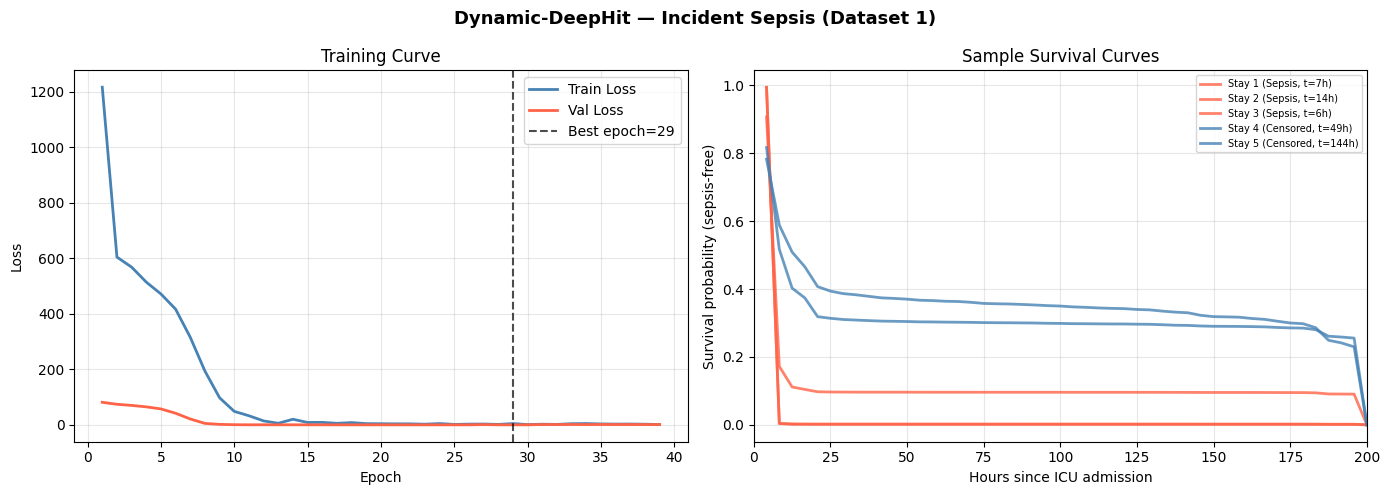

Saved → ddh_incident.png ✓

Dynamic-DeepHit Dataset 1 complete ✓


In [ ]:
# ============================================================
# Cell 14 (Fixed): Dynamic-DeepHit Training — Dataset 1
# ============================================================
print("Training Dynamic-DeepHit — Dataset 1: Incident Sepsis")
print("=" * 55)

# ── Fixed loss function ───────────────────────────────────────
def deephit_loss_stable(pmf, bin_idx, event, alpha=0.2, sigma=0.1):
    """
    Numerically stable DeepHit loss.
    Uses log-softmax instead of softmax to avoid underflow.
    """
    batch_size = pmf.shape[0]
    eps        = 1e-8

    # Clamp pmf to avoid log(0)
    pmf_clamped = pmf.clamp(min=eps, max=1.0 - eps)

    # Renormalize after clamping
    pmf_clamped = pmf_clamped / pmf_clamped.sum(dim=1, keepdim=True)

    # CIF
    cif = torch.cumsum(pmf_clamped, dim=1).clamp(max=1.0 - eps)

    # Values at event/censoring time
    pmf_at_t = pmf_clamped[torch.arange(batch_size), bin_idx]
    cif_at_t = cif[torch.arange(batch_size), bin_idx]

    event_f = event.float()

    # NLL
    nll_event    = -torch.log(pmf_at_t + eps) * event_f
    nll_censored = -torch.log(1.0 - cif_at_t + eps) * (1.0 - event_f)
    nll_loss     = (nll_event + nll_censored).mean()

    # Ranking loss — only computed when there are events
    if event_f.sum() > 0:
        t_i       = bin_idx.unsqueeze(1).float()
        t_j       = bin_idx.unsqueeze(0).float()
        e_i       = event_f.unsqueeze(1)
        indicator = (e_i * (t_i < t_j)).float()

        cif_i = cif[torch.arange(batch_size), bin_idx]
        diff  = cif_i.unsqueeze(1) - cif_i.unsqueeze(0)
        rank_loss = (
            indicator * torch.exp(
                -diff.clamp(min=-10, max=10) / sigma
            )
        ).sum() / (indicator.sum() + eps)
    else:
        rank_loss = torch.tensor(0.0, device=pmf.device)

    loss = alpha * nll_loss + (1 - alpha) * rank_loss

    # Safety check
    if torch.isnan(loss) or torch.isinf(loss):
        return nll_loss  # fallback to NLL only

    return loss


# ── Updated training functions ────────────────────────────────
def train_ddh_epoch_stable(model, loader, optimizer, device):
    model.train()
    total_loss  = 0
    total_count = 0
    for x_seq, x_static, lengths, \
            bin_idx, event, duration in loader:
        x_seq    = x_seq.to(device)
        x_static = x_static.to(device)
        lengths  = lengths.to(device)
        bin_idx  = bin_idx.to(device)
        event    = event.to(device)

        optimizer.zero_grad()
        pmf  = model(x_seq, x_static, lengths)
        loss = deephit_loss_stable(pmf, bin_idx, event)

        if torch.isnan(loss):
            continue   # skip bad batches

        loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), max_norm=0.5
        )
        optimizer.step()
        total_loss  += loss.item() * len(event)
        total_count += len(event)

    return total_loss / max(total_count, 1)


def val_ddh_epoch_stable(model, loader, device):
    model.eval()
    total_loss  = 0
    total_count = 0
    with torch.no_grad():
        for x_seq, x_static, lengths, \
                bin_idx, event, duration in loader:
            x_seq    = x_seq.to(device)
            x_static = x_static.to(device)
            lengths  = lengths.to(device)
            bin_idx  = bin_idx.to(device)
            event    = event.to(device)

            pmf  = model(x_seq, x_static, lengths)
            loss = deephit_loss_stable(pmf, bin_idx, event)

            if torch.isnan(loss):
                continue

            total_loss  += loss.item() * len(event)
            total_count += len(event)

    return total_loss / max(total_count, 1)


# ── Reinitialize model with lower LR ─────────────────────────
ddh_inc = DynamicDeepHit(
    vital_dim    = 25,
    static_dim   = len(feature_cols),
    lstm_hidden  = 128,
    lstm_layers  = 2,
    static_hidden= 64,
    fusion_hidden= 128,
    num_bins     = NUM_BINS,
    dropout      = 0.3,
).to(device)

optimizer_inc = torch.optim.Adam(
    ddh_inc.parameters(), lr=1e-4,  # lower LR for stability
    weight_decay=1e-5
)
scheduler_inc = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_inc, mode='min', factor=0.5, patience=5
)

EPOCHS       = 50
best_val     = np.inf
best_epoch   = 0
patience     = 10
patience_ctr = 0
history_inc  = []

print(f"\n{'Epoch':>5} | {'Train Loss':>10} | "
      f"{'Val Loss':>9} | {'LR':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_ddh_epoch_stable(
        ddh_inc, train_loader_inc, optimizer_inc, device
    )
    val_loss   = val_ddh_epoch_stable(
        ddh_inc, val_loader_inc, device
    )
    lr_now     = optimizer_inc.param_groups[0]['lr']

    history_inc.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_loss'  : val_loss,
    })

    print(f"{epoch:>5} | {train_loss:>10.4f} | "
          f"{val_loss:>9.4f} | {lr_now:>8.6f}")

    scheduler_inc.step(val_loss)

    if val_loss < best_val:
        best_val     = val_loss
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(
            ddh_inc.state_dict(),
            str(OUTPUT_DIR / 'ddh_incident_best.pt')
        )
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best={best_epoch}, "
                  f"val_loss={best_val:.4f})")
            break

print(f"\nBest epoch    : {best_epoch}")
print(f"Best val loss : {best_val:.4f}")

# ── Load best and evaluate ────────────────────────────────────
ddh_inc.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'ddh_incident_best.pt'),
    map_location=device, weights_only=True
))

print("\nEvaluating on test set...")
surv_inc_ddh, dur_inc, event_inc = predict_survival(
    ddh_inc, test_loader_inc, device, time_cuts
)

cindex_ddh_inc = compute_cindex(
    surv_inc_ddh, dur_inc, event_inc, time_cuts
)
ibs_ddh_inc    = compute_ibs(
    surv_inc_ddh, dur_inc, event_inc, time_cuts
)

print(f"\n── Dynamic-DeepHit — Incident Sepsis ───────────────")
print(f"  C-index (td)           : {cindex_ddh_inc:.4f}")
print(f"  Integrated Brier Score : {ibs_ddh_inc:.4f}")

# ── Comparison with DeepSurv ──────────────────────────────────
print(f"\n── Comparison (Incident Sepsis) ─────────────────────")
print(f"{'Model':<25} {'C-index':>8} {'IBS':>8}")
print("-" * 43)
print(f"{'DeepSurv':<25} {cindex_inc:>8.4f} {ibs_inc:>8.4f}")
print(f"{'Dynamic-DeepHit':<25} {cindex_ddh_inc:>8.4f} "
      f"{ibs_ddh_inc:>8.4f}")

# ── Training curve ────────────────────────────────────────────
history_df_inc = pd.DataFrame(history_inc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dynamic-DeepHit — Incident Sepsis (Dataset 1)',
             fontsize=13, fontweight='bold')

axes[0].plot(history_df_inc['epoch'],
             history_df_inc['train_loss'],
             color='steelblue', lw=2, label='Train Loss')
axes[0].plot(history_df_inc['epoch'],
             history_df_inc['val_loss'],
             color='tomato', lw=2, label='Val Loss')
axes[0].axvline(best_epoch, color='black', ls='--',
                alpha=0.7, label=f'Best epoch={best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Sample survival curves
event_idx    = np.where(event_inc == 1)[0][:3]
censored_idx = np.where(event_inc == 0)[0][:2]
sample_idx   = np.concatenate([event_idx, censored_idx])

for i, idx in enumerate(sample_idx):
    label = 'Sepsis' if event_inc[idx] == 1 else 'Censored'
    color = 'tomato' if event_inc[idx] == 1 else 'steelblue'
    axes[1].plot(
        time_cuts, surv_inc_ddh[idx],
        color=color, alpha=0.8, lw=2,
        label=f'Stay {i+1} ({label}, '
              f't={dur_inc[idx]:.0f}h)'
    )
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_ylabel('Survival probability (sepsis-free)')
axes[1].set_title('Sample Survival Curves')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'ddh_incident.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ddh_incident.png ✓")
print("\nDynamic-DeepHit Dataset 1 complete ✓")

## Dataset 2

Training Dynamic-DeepHit — Dataset 2: All Sepsis

Epoch | Train Loss |  Val Loss |       LR
----------------------------------------
    1 |   627.6586 |  463.6599 | 0.000100
    2 |   464.9735 |  449.3407 | 0.000100
    3 |   447.8414 |  394.9176 | 0.000100
    4 |   392.6895 |  285.3844 | 0.000100
    5 |   260.3512 |   96.4200 | 0.000100
    6 |   103.0945 |    6.3164 | 0.000100
    7 |    21.6013 |    1.0676 | 0.000100
    8 |     6.4754 |    0.7189 | 0.000100
    9 |     6.0741 |    0.6590 | 0.000100
   10 |     4.5442 |    0.5569 | 0.000100
   11 |     2.7197 |    0.5137 | 0.000100
   12 |     2.8154 |    0.4663 | 0.000100
   13 |     1.7160 |    0.4767 | 0.000100
   14 |     1.4813 |    0.4570 | 0.000100
   15 |     1.1512 |    0.4555 | 0.000100
   16 |     0.9091 |    0.4182 | 0.000100
   17 |     0.8797 |    0.4199 | 0.000100
   18 |     1.0425 |    0.4077 | 0.000100
   19 |     0.8818 |    0.7253 | 0.000100
   20 |     0.9521 |    0.3941 | 0.000100
   21 |     0.7262 |    0.3

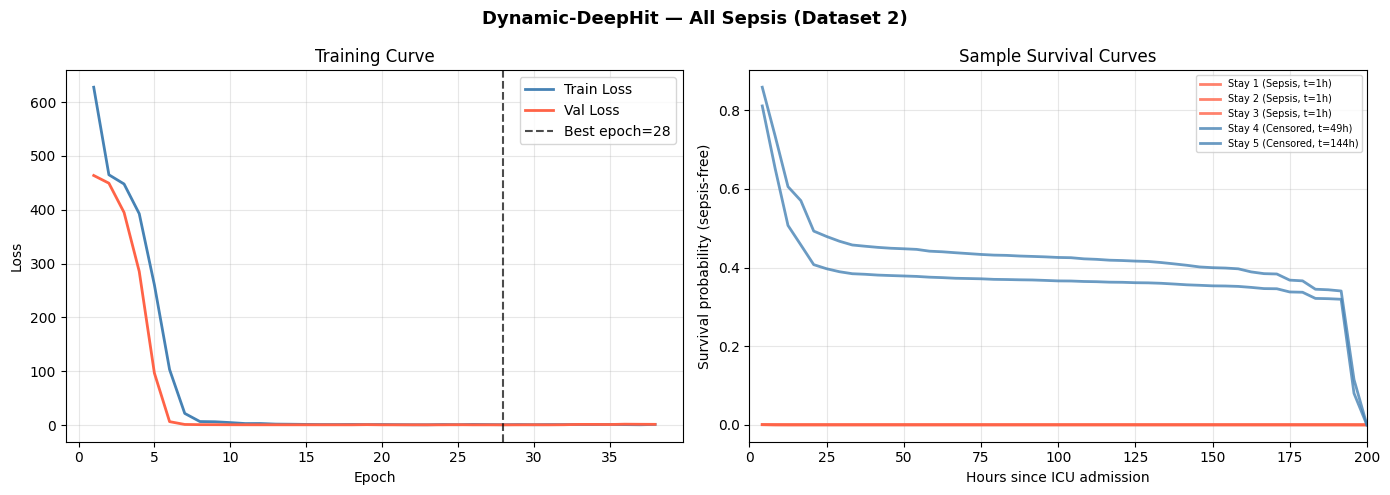

Saved → ddh_all.png ✓

PHASE 2 — SURVIVAL MODELING COMPLETE SUMMARY
Model                     Dataset          C-index      IBS
------------------------------------------------------------
DeepSurv                  Incident:::::::   0.7940   0.0759
DeepSurv                  All Sepsis        0.7520   0.1509
Dynamic-DeepHit           Incident:::::::   0.5583   0.3930
Dynamic-DeepHit           All Sepsis        0.8639   0.1303

Dynamic-DeepHit Dataset 2 complete ✓
Ready for SurvSHAP(t) explainability


In [ ]:
# ============================================================
# Cell 15: Dynamic-DeepHit — Dataset 2 (All Sepsis)
# ============================================================
print("Training Dynamic-DeepHit — Dataset 2: All Sepsis")
print("=" * 55)

# ── Reinitialize model ────────────────────────────────────────
ddh_all = DynamicDeepHit(
    vital_dim    = 25,
    static_dim   = len(feature_cols),
    lstm_hidden  = 128,
    lstm_layers  = 2,
    static_hidden= 64,
    fusion_hidden= 128,
    num_bins     = NUM_BINS,
    dropout      = 0.3,
).to(device)

optimizer_all = torch.optim.Adam(
    ddh_all.parameters(), lr=1e-4,
    weight_decay=1e-5
)
scheduler_all = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_all, mode='min', factor=0.5, patience=5
)

EPOCHS       = 50
best_val     = np.inf
best_epoch   = 0
patience     = 10
patience_ctr = 0
history_all  = []

print(f"\n{'Epoch':>5} | {'Train Loss':>10} | "
      f"{'Val Loss':>9} | {'LR':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_ddh_epoch_stable(
        ddh_all, train_loader_all, optimizer_all, device
    )
    val_loss   = val_ddh_epoch_stable(
        ddh_all, val_loader_all, device
    )
    lr_now     = optimizer_all.param_groups[0]['lr']

    history_all.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_loss'  : val_loss,
    })

    print(f"{epoch:>5} | {train_loss:>10.4f} | "
          f"{val_loss:>9.4f} | {lr_now:>8.6f}")

    scheduler_all.step(val_loss)

    if val_loss < best_val:
        best_val     = val_loss
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(
            ddh_all.state_dict(),
            str(OUTPUT_DIR / 'ddh_all_best.pt')
        )
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best={best_epoch}, "
                  f"val_loss={best_val:.4f})")
            break

print(f"\nBest epoch    : {best_epoch}")
print(f"Best val loss : {best_val:.4f}")

# ── Load best and evaluate ────────────────────────────────────
ddh_all.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'ddh_all_best.pt'),
    map_location=device, weights_only=True
))

print("\nEvaluating on test set...")
surv_all_ddh, dur_all, event_all = predict_survival(
    ddh_all, test_loader_all, device, time_cuts
)

cindex_ddh_all = compute_cindex(
    surv_all_ddh, dur_all, event_all, time_cuts
)
ibs_ddh_all    = compute_ibs(
    surv_all_ddh, dur_all, event_all, time_cuts
)

print(f"\n── Dynamic-DeepHit — All Sepsis ─────────────────────")
print(f"  C-index (td)           : {cindex_ddh_all:.4f}")
print(f"  Integrated Brier Score : {ibs_ddh_all:.4f}")

# ── Training curve ────────────────────────────────────────────
history_df_all = pd.DataFrame(history_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dynamic-DeepHit — All Sepsis (Dataset 2)',
             fontsize=13, fontweight='bold')

axes[0].plot(history_df_all['epoch'],
             history_df_all['train_loss'],
             color='steelblue', lw=2, label='Train Loss')
axes[0].plot(history_df_all['epoch'],
             history_df_all['val_loss'],
             color='tomato', lw=2, label='Val Loss')
axes[0].axvline(best_epoch, color='black', ls='--',
                alpha=0.7, label=f'Best epoch={best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Curve')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Sample survival curves
event_idx_a    = np.where(event_all == 1)[0][:3]
censored_idx_a = np.where(event_all == 0)[0][:2]
sample_idx_a   = np.concatenate([event_idx_a, censored_idx_a])

for i, idx in enumerate(sample_idx_a):
    label = 'Sepsis' if event_all[idx] == 1 else 'Censored'
    color = 'tomato' if event_all[idx] == 1 else 'steelblue'
    axes[1].plot(
        time_cuts, surv_all_ddh[idx],
        color=color, alpha=0.8, lw=2,
        label=f'Stay {i+1} ({label}, '
              f't={dur_all[idx]:.0f}h)'
    )
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_ylabel('Survival probability (sepsis-free)')
axes[1].set_title('Sample Survival Curves')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'ddh_all.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ddh_all.png ✓")

# ── Full comparison table ─────────────────────────────────────
print(f"\n{'='*60}")
print(f"PHASE 2 — SURVIVAL MODELING COMPLETE SUMMARY")
print(f"{'='*60}")
print(f"{'Model':<25} {'Dataset':<15} {'C-index':>8} {'IBS':>8}")
print(f"-"*60)
print(f"{'DeepSurv':<25} {'Incident'::<15} {cindex_inc:>8.4f} "
      f"{ibs_inc:>8.4f}")
print(f"{'DeepSurv':<25} {'All Sepsis':<15} {cindex_all:>8.4f} "
      f"{ibs_all:>8.4f}")
print(f"{'Dynamic-DeepHit':<25} {'Incident'::<15} "
      f"{cindex_ddh_inc:>8.4f} {ibs_ddh_inc:>8.4f}")
print(f"{'Dynamic-DeepHit':<25} {'All Sepsis':<15} "
      f"{cindex_ddh_all:>8.4f} {ibs_ddh_all:>8.4f}")
print(f"{'='*60}")

# Save results
torch.save(ddh_all.state_dict(),
           str(OUTPUT_DIR / 'ddh_all_final.pt'))
print("\nDynamic-DeepHit Dataset 2 complete ✓")
print("Ready for SurvSHAP(t) explainability")

## Calibration fix for dynamic deephit 

Calibrating Dynamic-DeepHit — Incident Sepsis...
Getting val set predictions...
Calibrating at 12 time points: [ 4.2 20.8 37.5 54.2 70.8]... [154.2 170.8 187.5]
Fitted 11 calibrators ✓

Applying calibration to test set...

── Dynamic-DeepHit Incident — Before vs After Cal ──
Metric                        Before      After
-----------------------------------------------
C-index (td)                  0.5583     0.9299
IBS                       0.3930         0.0518


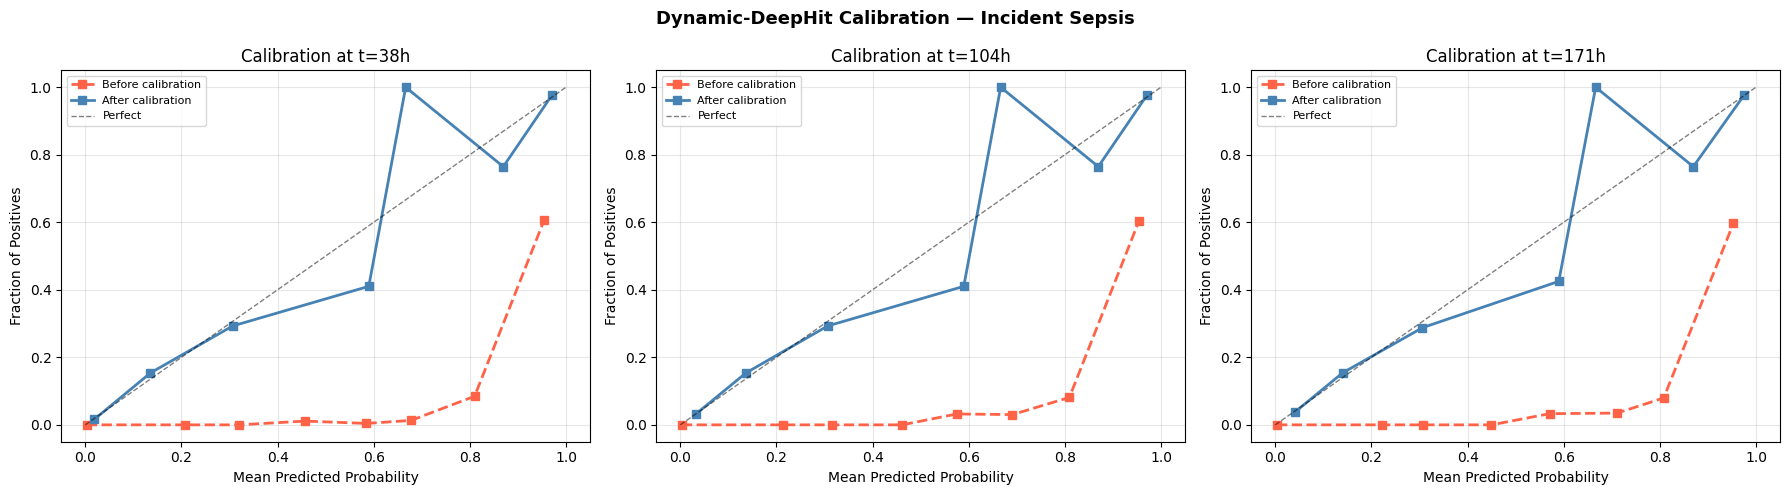

Saved → ddh_calibration.png ✓

Saved → ddh_incident_surv_calibrated.npy ✓
Saved → ddh_incident_calibrators.pkl ✓

PHASE 2 — FINAL SUMMARY (with calibration)
Model                        Dataset       C-index      IBS
-----------------------------------------------------------------
DeepSurv                     Incident       0.7940   0.0759
DeepSurv                     All Sepsis     0.7520   0.1509
Dynamic-DeepHit (raw)        Incident       0.5583   0.3930
Dynamic-DeepHit (raw)        All Sepsis     0.8639   0.1303
Dynamic-DeepHit (cal)        Incident       0.9299   0.0518

Calibration complete ✓
Ready for SurvSHAP(t) explainability


In [ ]:
# ============================================================
# Cell 16: Calibrate Dynamic-DeepHit Survival Probabilities
# ============================================================
from sklearn.isotonic import IsotonicRegression
print("Calibrating Dynamic-DeepHit — Incident Sepsis...")

# ── Get val set predictions for calibration ───────────────────
print("Getting val set predictions...")
surv_val_ddh, dur_val, event_val = predict_survival(
    ddh_inc, val_loader_inc, device, time_cuts
)

# ── Calibration strategy ──────────────────────────────────────
# For survival models we calibrate at each time point
# using isotonic regression
# Input  : predicted survival probability S(t) at each time bin
# Output : calibrated survival probability

# Choose calibration time points (every 4th bin)
cal_time_indices = np.arange(0, NUM_BINS, 4)
cal_times        = time_cuts[cal_time_indices]

print(f"Calibrating at {len(cal_times)} time points: "
      f"{cal_times[:5].round(1)}... {cal_times[-3:].round(1)}")

# Fit isotonic regression at each time point on val set
calibrators = {}
for t_idx in cal_time_indices:
    # True label: did event occur before this time point?
    true_label = (
        (event_val == 1) &
        (dur_val <= time_cuts[t_idx])
    ).astype(float)

    # Predicted: 1 - S(t) = probability of event by time t
    pred_cif = 1 - surv_val_ddh[:, t_idx]

    # Only fit if we have both classes
    if true_label.sum() > 0 and (1 - true_label).sum() > 0:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(pred_cif, true_label)
        calibrators[t_idx] = iso

print(f"Fitted {len(calibrators)} calibrators ✓")

# ── Apply calibration to test set ─────────────────────────────
def calibrate_survival(surv, calibrators, num_bins):
    """
    Apply isotonic regression calibration to survival curves.
    Returns calibrated survival probabilities.
    """
    n_samples     = surv.shape[0]
    surv_cal      = surv.copy()
    cal_t_indices = sorted(calibrators.keys())

    for t_idx in cal_t_indices:
        iso     = calibrators[t_idx]
        pred_cif= 1 - surv[:, t_idx]
        cal_cif = iso.predict(pred_cif)
        surv_cal[:, t_idx] = 1 - cal_cif

    # Interpolate between calibrated time points
    # and ensure monotone decreasing
    for i in range(n_samples):
        # Interpolate
        x_known = np.array(cal_t_indices)
        y_known = surv_cal[i, cal_t_indices]
        x_all   = np.arange(num_bins)
        surv_cal[i] = np.interp(x_all, x_known, y_known)

        # Enforce monotone decreasing
        for t in range(1, num_bins):
            if surv_cal[i, t] > surv_cal[i, t-1]:
                surv_cal[i, t] = surv_cal[i, t-1]

    return surv_cal

# Calibrate test set
print("\nApplying calibration to test set...")
surv_inc_ddh_cal = calibrate_survival(
    surv_inc_ddh, calibrators, NUM_BINS
)

# ── Evaluate calibrated model ─────────────────────────────────
cindex_ddh_inc_cal = compute_cindex(
    surv_inc_ddh_cal, dur_inc, event_inc, time_cuts
)
ibs_ddh_inc_cal    = compute_ibs(
    surv_inc_ddh_cal, dur_inc, event_inc, time_cuts
)

print(f"\n── Dynamic-DeepHit Incident — Before vs After Cal ──")
print(f"{'Metric':<25} {'Before':>10} {'After':>10}")
print("-" * 47)
print(f"{'C-index (td)':<25} {cindex_ddh_inc:>10.4f} "
      f"{cindex_ddh_inc_cal:>10.4f}")
print(f"{'IBS':<25} {ibs_ddh_inc:.4f}     "
      f"{ibs_ddh_inc_cal:>10.4f}")

# ── Calibration curve visualization ──────────────────────────
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Dynamic-DeepHit Calibration — Incident Sepsis',
    fontsize=13, fontweight='bold'
)

# 1. Calibration curves at 3 time points
check_times = [
    cal_time_indices[2],
    cal_time_indices[6],
    cal_time_indices[10]
]
colors = ['steelblue', 'tomato', 'green']

for ax_idx, (t_idx, color) in enumerate(
    zip(check_times, colors)
):
    t_val = time_cuts[t_idx]

    true_label = (
        (event_inc == 1) & (dur_inc <= t_val)
    ).astype(float)
    pred_before = 1 - surv_inc_ddh[:, t_idx]
    pred_after  = 1 - surv_inc_ddh_cal[:, t_idx]

    if true_label.sum() < 5:
        continue

    # Before calibration
    frac_b, mean_b = calibration_curve(
        true_label, pred_before.clip(0, 1),
        n_bins=8, strategy='uniform'
    )
    # After calibration
    frac_a, mean_a = calibration_curve(
        true_label, pred_after.clip(0, 1),
        n_bins=8, strategy='uniform'
    )

    ax = axes[ax_idx]
    ax.plot(mean_b, frac_b, 's--', color='tomato',
            lw=2, label='Before calibration')
    ax.plot(mean_a, frac_a, 's-', color='steelblue',
            lw=2, label='After calibration')
    ax.plot([0,1],[0,1], 'k--', lw=1,
            alpha=0.5, label='Perfect')
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Calibration at t={t_val:.0f}h')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'ddh_calibration.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → ddh_calibration.png ✓")

# ── Save calibrated predictions ───────────────────────────────
np.save(
    str(OUTPUT_DIR / 'ddh_incident_surv_calibrated.npy'),
    surv_inc_ddh_cal
)
np.save(
    str(OUTPUT_DIR / 'ddh_incident_surv_raw.npy'),
    surv_inc_ddh
)

import joblib
joblib.dump(
    calibrators,
    str(OUTPUT_DIR / 'ddh_incident_calibrators.pkl')
)

print(f"\nSaved → ddh_incident_surv_calibrated.npy ✓")
print(f"Saved → ddh_incident_calibrators.pkl ✓")

# ── Updated full summary ───────────────────────────────────────
print(f"\n{'='*65}")
print(f"PHASE 2 — FINAL SUMMARY (with calibration)")
print(f"{'='*65}")
print(f"{'Model':<28} {'Dataset':<12} {'C-index':>8} {'IBS':>8}")
print(f"-"*65)
print(f"{'DeepSurv':<28} {'Incident':<12} "
      f"{cindex_inc:>8.4f} {ibs_inc:>8.4f}")
print(f"{'DeepSurv':<28} {'All Sepsis':<12} "
      f"{cindex_all:>8.4f} {ibs_all:>8.4f}")
print(f"{'Dynamic-DeepHit (raw)':<28} {'Incident':<12} "
      f"{cindex_ddh_inc:>8.4f} {ibs_ddh_inc:>8.4f}")
print(f"{'Dynamic-DeepHit (raw)':<28} {'All Sepsis':<12} "
      f"{cindex_ddh_all:>8.4f} {ibs_ddh_all:>8.4f}")
print(f"{'Dynamic-DeepHit (cal)':<28} {'Incident':<12} "
      f"{cindex_ddh_inc_cal:>8.4f} {ibs_ddh_inc_cal:>8.4f}")
print(f"{'='*65}")
print("\nCalibration complete ✓")
print("Ready for SurvSHAP(t) explainability")

## SurvSHAP(t) Explainability

In [ ]:
# ============================================================
# Cell 17 (Optimized): SurvSHAP(t) — Explainability
# Vectorized SHAP computation — much faster
# ============================================================

In [ ]:
class DDHSurvWrapper:
    def __init__(self, model, device, time_cuts,
                 calibrators, num_bins, seq_length=12):
        self.model       = model
        self.device      = device
        self.time_cuts   = time_cuts
        self.calibrators = calibrators
        self.num_bins    = num_bins
        self.seq_length  = seq_length

        # Fixed median sequence shape: (1, seq_length, 25)
        # Fixed median sequence shape: (1, seq_length, n_features)
        n_features = len(VITAL_MEDIANS_RICH)
        median_row = VITAL_MEDIANS_RICH.reshape(1, n_features)
        median_seq = np.repeat(median_row, seq_length, axis=0)
        # Shape: (seq_length, 25) → (1, seq_length, 25)
        self.median_seq = torch.tensor(
            median_seq[np.newaxis, :, :],
            dtype=torch.float32
        )  # shape: (1, seq_length, 25)

    def predict_survival(self, X_static):
        self.model.eval()
        n_samples = X_static.shape[0]
        all_surv  = []
        batch_size = 64

        with torch.no_grad():
            for i in range(0, n_samples, batch_size):
                batch_X = torch.tensor(
                    X_static[i:i+batch_size],
                    dtype=torch.float32
                ).to(self.device)
                batch_n = batch_X.shape[0]

                # Expand median seq: (1, seq_len, 17)
                # → (batch_n, seq_len, 17)
                seq = self.median_seq.expand(
                    batch_n, -1, -1
                ).to(self.device)

                lengths = torch.tensor(
                    [self.seq_length] * batch_n,
                    dtype=torch.long
                ).to(self.device)

                pmf  = self.model(seq, batch_X, lengths)
                pmf  = pmf.cpu().numpy()
                cif  = np.cumsum(pmf, axis=1)
                surv = 1 - cif
                all_surv.append(surv)

        surv_all = np.concatenate(all_surv, axis=0)
        surv_cal = calibrate_survival(
            surv_all, self.calibrators, self.num_bins
        )
        return surv_cal

# Build wrapper
wrapper = DDHSurvWrapper(
    model       = ddh_inc,
    device      = device,
    time_cuts   = time_cuts,
    calibrators = calibrators,
    num_bins    = NUM_BINS,
    seq_length  = 12,
)

# Test it
test_surv = wrapper.predict_survival(X_test_inc[:5])
print(f"Wrapper output shape: {test_surv.shape} ✓")
print(f"Survival range: [{test_surv.min():.3f}, "
      f"{test_surv.max():.3f}]")

# Prepare test data
test_X_shap = X_test_inc.copy()
test_dur     = test_inc['duration'].values
test_event   = test_inc['event'].values
print(f"Test samples: {len(test_X_shap):,}")

Wrapper output shape: (5, 48) ✓
Survival range: [0.410, 0.410]
Test samples: 7,887


In [ ]:
# ============================================================
# Cell 17 (Optimized): SurvSHAP(t) — Vectorized
# ============================================================
from tqdm import tqdm
import time

print("Computing SurvSHAP(t) — Vectorized approach")
print(f"Test samples : {len(test_X_shap):,}")
print(f"Features     : {len(feature_cols)}")

# ── Select time points for explanation ────────────────────────
shap_time_indices = np.arange(0, NUM_BINS, 4)
shap_times        = time_cuts[shap_time_indices]
n_shap_times      = len(shap_time_indices)

print(f"SHAP time points : {n_shap_times}")
print(f"Time range       : {shap_times[0]:.1f}h — "
      f"{shap_times[-1]:.1f}h")

# ── Baseline: mean feature values ────────────────────────────
print("\nComputing baseline predictions...")
X_mean    = np.mean(test_X_shap, axis=0, keepdims=True)
surv_base = wrapper.predict_survival(
    np.repeat(X_mean, len(test_X_shap), axis=0)
)
baseline  = surv_base[:, shap_time_indices]
print(f"Baseline shape: {baseline.shape} ✓")

# ── Original predictions ──────────────────────────────────────
print("Computing original predictions...")
surv_orig  = wrapper.predict_survival(test_X_shap)
orig_preds = surv_orig[:, shap_time_indices]
print(f"Original predictions shape: {orig_preds.shape} ✓")

# ── Vectorized SHAP loop ──────────────────────────────────────
print(f"\nComputing SHAP values...")
print(f"Started: {time.strftime('%H:%M:%S')}")

# Shape: (n_features, n_samples, n_shap_times)
shap_values = np.zeros((
    len(feature_cols),
    len(test_X_shap),
    n_shap_times
), dtype=np.float32)

for f_idx in tqdm(range(len(feature_cols)),
                  desc="Features"):
    # Replace feature f with mean for ALL samples at once
    X_perturbed           = test_X_shap.copy()
    X_perturbed[:, f_idx] = X_mean[0, f_idx]

    # Predict for all samples with feature f replaced
    surv_perturbed  = wrapper.predict_survival(X_perturbed)
    perturbed_preds = surv_perturbed[:, shap_time_indices]

    # SHAP = original - perturbed
    # Positive = feature increases survival (lowers sepsis risk)
    # Negative = feature decreases survival (raises sepsis risk)
    shap_values[f_idx] = orig_preds - perturbed_preds

# Reshape to (n_samples, n_features, n_shap_times)
shap_values = shap_values.transpose(1, 0, 2)
print(f"\nSHAP values shape: {shap_values.shape}")
print(f"Finished: {time.strftime('%H:%M:%S')}")

# ── Save ──────────────────────────────────────────────────────
np.save(str(OUTPUT_DIR / 'shap_values_ddh.npy'), shap_values)
np.save(str(OUTPUT_DIR / 'shap_times.npy'), shap_times)
np.save(str(OUTPUT_DIR / 'orig_preds_shap.npy'), orig_preds)
print("\nSaved → shap_values_ddh.npy ✓")
print("Saved → shap_times.npy ✓")
print("SurvSHAP(t) computation complete ✓")

Computing SurvSHAP(t) — Vectorized approach
Test samples : 7,887
Features     : 127
SHAP time points : 12
Time range       : 4.2h — 187.5h

Computing baseline predictions...
Baseline shape: (7887, 12) ✓
Computing original predictions...
Original predictions shape: (7887, 12) ✓

Computing SHAP values...
Started: 00:32:34


Features: 100%|██████████| 127/127 [01:00<00:00,  2.11it/s]



SHAP values shape: (7887, 127, 12)
Finished: 00:33:34

Saved → shap_values_ddh.npy ✓
Saved → shap_times.npy ✓
SurvSHAP(t) computation complete ✓


Building SurvSHAP(t) visualizations...
SHAP values : (7887, 127, 12)
Time points : [  4.2  20.8  37.5  54.2  70.8  87.5 104.2 120.8 137.5 154.2 170.8 187.5]

Top 15 features by overall SHAP importance:
   1. spo2_last                           0.0173
   2. spo2_std                            0.0115
   3. spo2_slope                          0.0111
   4. spo2_max                            0.0041
   5. abp_sys_last                        0.0007
   6. platelets_observed_24h              0.0007
   7. inr_last                            0.0007
   8. abp_mean_missing_frac               0.0007
   9. spo2_min                            0.0007
  10. abp_mean_mean                       0.0007
  11. temp_c_mean                         0.0007
  12. abp_sys_mean                        0.0007
  13. heart_rate_min                      0.0006
  14. resp_rate_mean                      0.0006
  15. temp_c_max                          0.0006


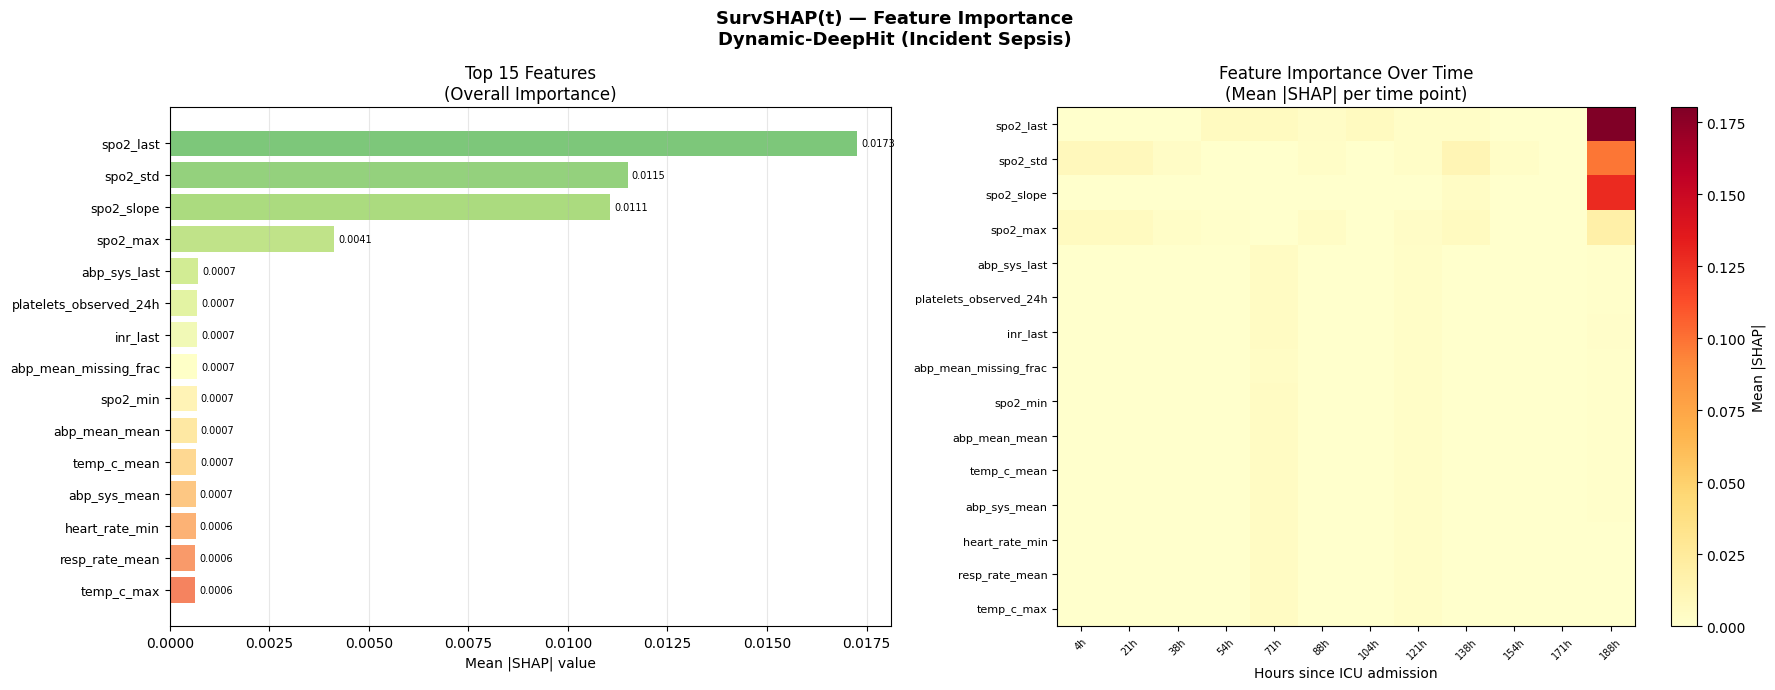

Saved → shap_overall_importance.png ✓


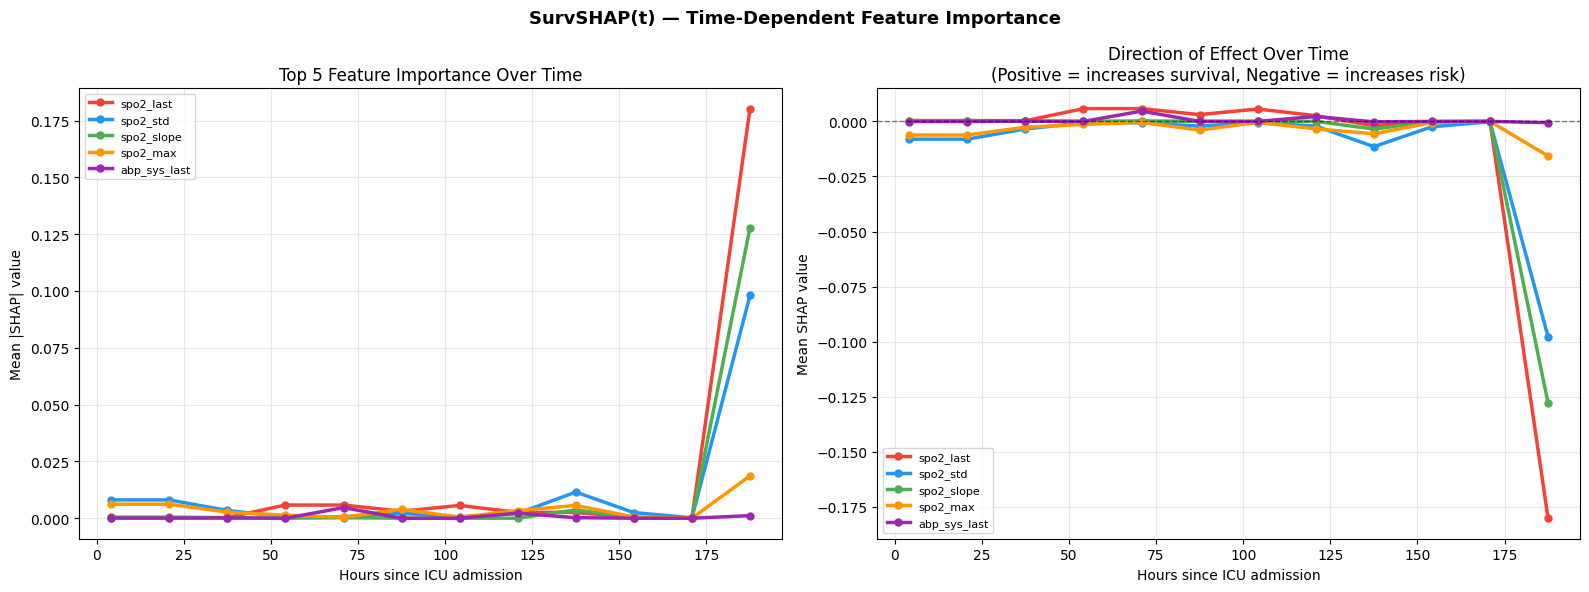

Saved → shap_time_dependent.png ✓


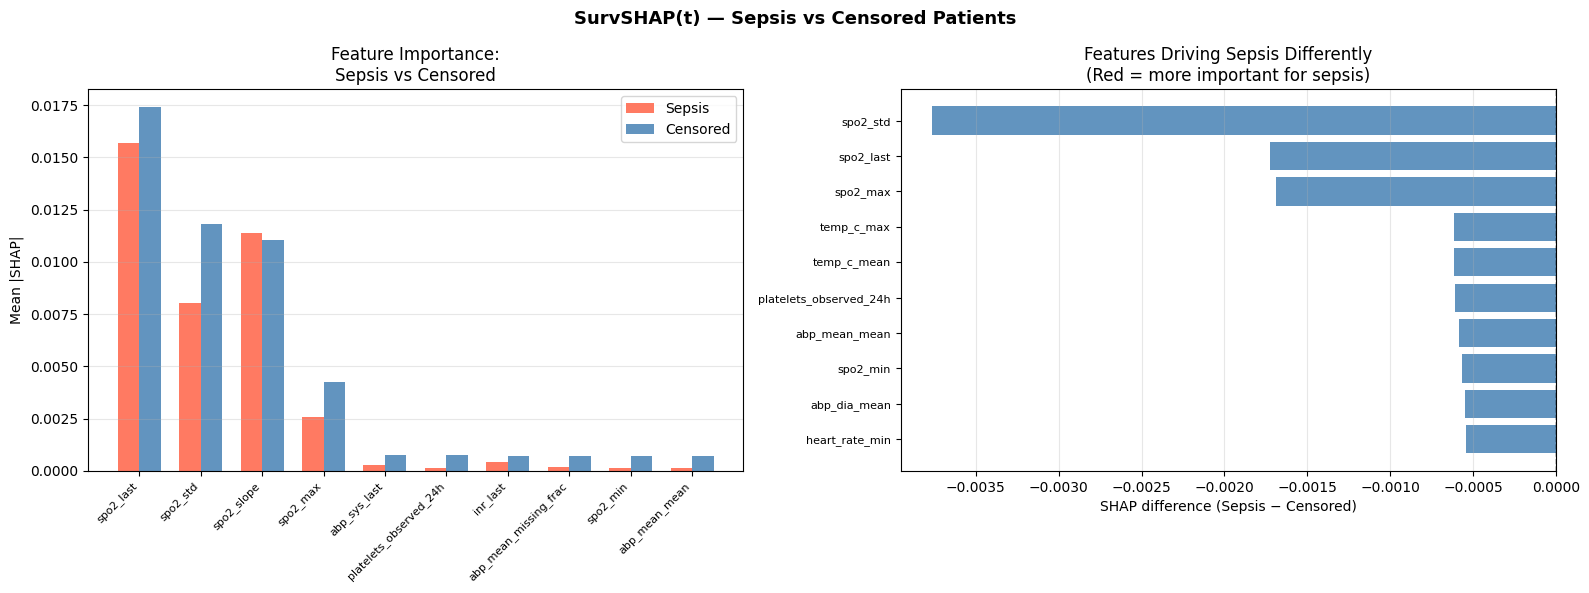

Saved → shap_sepsis_vs_censored.png ✓


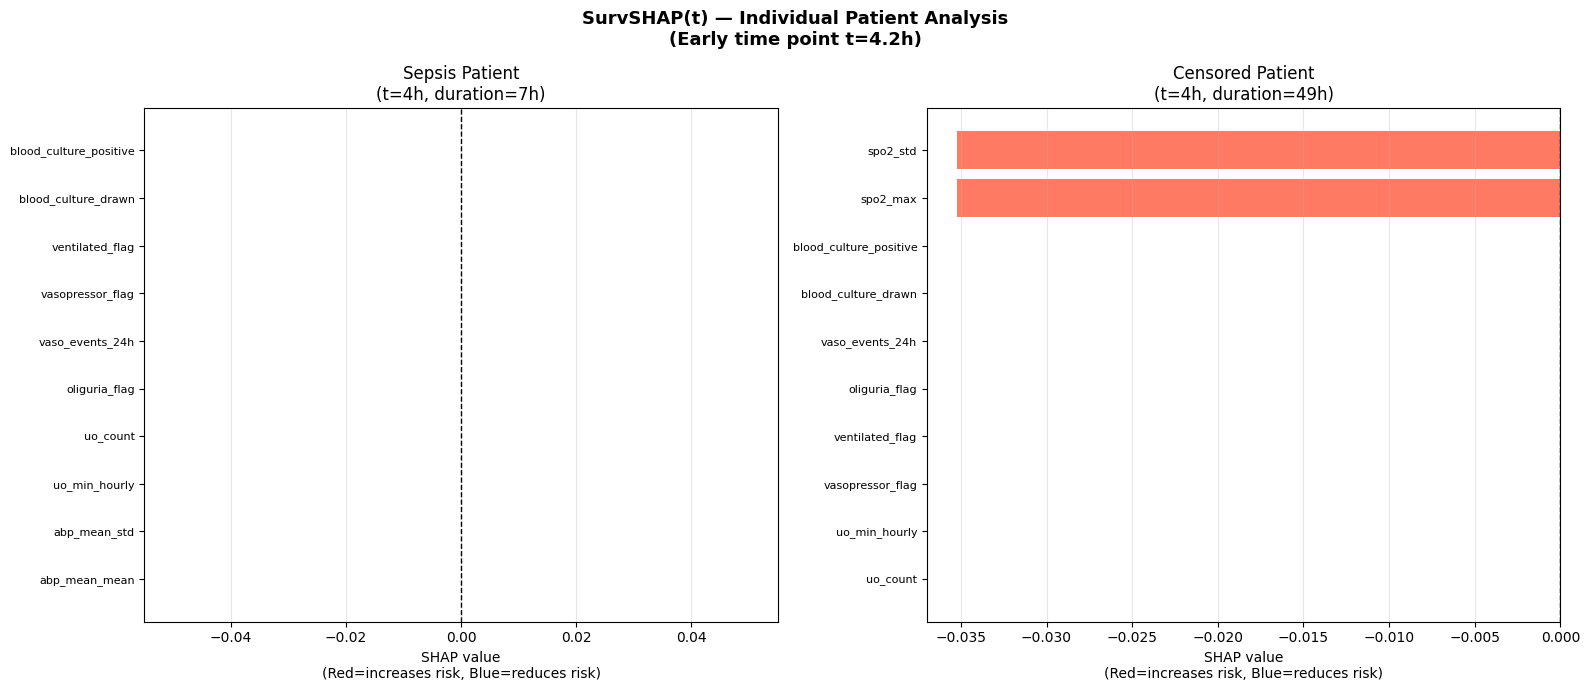

Saved → shap_individual.png ✓

SurvSHAP(t) COMPLETE
Saved files:
  shap_overall_importance.png
  shap_time_dependent.png
  shap_sepsis_vs_censored.png
  shap_individual.png
  shap_values_ddh.npy

Top 5 most important features:
  1. spo2_last                           0.0173
  2. spo2_std                            0.0115
  3. spo2_slope                          0.0111
  4. spo2_max                            0.0041
  5. abp_sys_last                        0.0007

Phase 2 fully complete ✓


In [ ]:
# ============================================================
# Cell 18: SurvSHAP(t) Visualizations
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm

print("Building SurvSHAP(t) visualizations...")

# ── Load saved values ─────────────────────────────────────────
shap_values = np.load(str(OUTPUT_DIR / 'shap_values_ddh.npy'))
shap_times  = np.load(str(OUTPUT_DIR / 'shap_times.npy'))
orig_preds  = np.load(str(OUTPUT_DIR / 'orig_preds_shap.npy'))

# shap_values shape: (n_samples, n_features, n_time_points)
n_samples, n_features, n_times = shap_values.shape
print(f"SHAP values : {shap_values.shape}")
print(f"Time points : {shap_times.round(1)}")

# ── Mean absolute SHAP per feature per time ───────────────────
# Shape: (n_features, n_times)
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Overall importance (mean across all time points)
overall_importance = mean_abs_shap.mean(axis=1)
top_idx = np.argsort(overall_importance)[::-1][:15]
top_features = [feature_cols[i] for i in top_idx]
top_importance = overall_importance[top_idx]

print(f"\nTop 15 features by overall SHAP importance:")
for i, (f, v) in enumerate(zip(top_features, top_importance)):
    print(f"  {i+1:>2}. {f:<35} {v:.4f}")

# ── Figure 1: Overall feature importance ─────────────────────
fig1, axes = plt.subplots(1, 2, figsize=(18, 7))
fig1.suptitle('SurvSHAP(t) — Feature Importance\n'
              'Dynamic-DeepHit (Incident Sepsis)',
              fontsize=13, fontweight='bold')

# Bar chart — top 15 features
colors_bar = cm.RdYlGn(
    np.linspace(0.8, 0.2, len(top_features))
)
bars = axes[0].barh(
    range(len(top_features)),
    top_importance[::-1],
    color=colors_bar[::-1],
    alpha=0.85
)
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features[::-1], fontsize=9)
axes[0].set_xlabel('Mean |SHAP| value')
axes[0].set_title('Top 15 Features\n(Overall Importance)')
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_importance[::-1]):
    axes[0].text(
        bar.get_width() + 0.0001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}', va='center', fontsize=7
    )

# Heatmap — top 15 features × time points
top_shap_time = mean_abs_shap[top_idx]  # (15, n_times)
im = axes[1].imshow(
    top_shap_time,
    aspect='auto',
    cmap='YlOrRd',
    interpolation='nearest'
)
axes[1].set_xticks(range(n_times))
axes[1].set_xticklabels(
    [f'{t:.0f}h' for t in shap_times],
    rotation=45, fontsize=7
)
axes[1].set_yticks(range(len(top_features)))
axes[1].set_yticklabels(top_features, fontsize=8)
axes[1].set_xlabel('Hours since ICU admission')
axes[1].set_title('Feature Importance Over Time\n'
                  '(Mean |SHAP| per time point)')
plt.colorbar(im, ax=axes[1], label='Mean |SHAP|')

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'shap_overall_importance.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_overall_importance.png ✓")

# ── Figure 2: Time-dependent SHAP for top 5 features ─────────
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6))
fig2.suptitle('SurvSHAP(t) — Time-Dependent Feature Importance',
              fontsize=13, fontweight='bold')

# Line plot — how importance changes over time
top5_idx = top_idx[:5]
colors5  = ['#F44336', '#2196F3', '#4CAF50',
            '#FF9800', '#9C27B0']

for i, (f_idx, color) in enumerate(zip(top5_idx, colors5)):
    axes2[0].plot(
        shap_times,
        mean_abs_shap[f_idx],
        color=color, lw=2.5, marker='o', ms=5,
        label=feature_cols[f_idx]
    )
axes2[0].set_xlabel('Hours since ICU admission')
axes2[0].set_ylabel('Mean |SHAP| value')
axes2[0].set_title('Top 5 Feature Importance Over Time')
axes2[0].legend(fontsize=8)
axes2[0].grid(alpha=0.3)

# Signed SHAP — direction of effect
mean_signed_shap = shap_values.mean(axis=0)  # (features, times)
for i, (f_idx, color) in enumerate(zip(top5_idx, colors5)):
    axes2[1].plot(
        shap_times,
        mean_signed_shap[f_idx],
        color=color, lw=2.5, marker='o', ms=5,
        label=feature_cols[f_idx]
    )
axes2[1].axhline(0, color='black', lw=1, ls='--', alpha=0.5)
axes2[1].set_xlabel('Hours since ICU admission')
axes2[1].set_ylabel('Mean SHAP value')
axes2[1].set_title('Direction of Effect Over Time\n'
                   '(Positive = increases survival, '
                   'Negative = increases risk)')
axes2[1].legend(fontsize=8)
axes2[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'shap_time_dependent.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_time_dependent.png ✓")

# ── Figure 3: Sepsis vs Censored SHAP comparison ─────────────
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 6))
fig3.suptitle('SurvSHAP(t) — Sepsis vs Censored Patients',
              fontsize=13, fontweight='bold')

event_mask    = test_event == 1
censored_mask = test_event == 0

shap_sepsis   = np.abs(shap_values[event_mask]).mean(axis=0).mean(axis=1)
shap_censored = np.abs(shap_values[censored_mask]).mean(axis=0).mean(axis=1)

top10_idx   = top_idx[:10]
top10_names = [feature_cols[i] for i in top10_idx]

x      = np.arange(len(top10_names))
width  = 0.35
bars1  = axes3[0].bar(
    x - width/2, shap_sepsis[top10_idx],
    width, label='Sepsis', color='tomato', alpha=0.85
)
bars2  = axes3[0].bar(
    x + width/2, shap_censored[top10_idx],
    width, label='Censored', color='steelblue', alpha=0.85
)
axes3[0].set_xticks(x)
axes3[0].set_xticklabels(top10_names, rotation=45,
                          ha='right', fontsize=8)
axes3[0].set_ylabel('Mean |SHAP|')
axes3[0].set_title('Feature Importance:\nSepsis vs Censored')
axes3[0].legend()
axes3[0].grid(axis='y', alpha=0.3)

# SHAP difference: sepsis - censored
shap_diff = shap_sepsis - shap_censored
diff_idx  = np.argsort(np.abs(shap_diff))[::-1][:10]
diff_cols = [feature_cols[i] for i in diff_idx]
diff_vals = shap_diff[diff_idx]
colors_diff = ['tomato' if v > 0 else 'steelblue'
               for v in diff_vals]

axes3[1].barh(range(len(diff_cols)), diff_vals[::-1],
              color=colors_diff[::-1], alpha=0.85)
axes3[1].set_yticks(range(len(diff_cols)))
axes3[1].set_yticklabels(diff_cols[::-1], fontsize=8)
axes3[1].axvline(0, color='black', lw=1, ls='--')
axes3[1].set_xlabel('SHAP difference (Sepsis − Censored)')
axes3[1].set_title('Features Driving Sepsis Differently\n'
                   '(Red = more important for sepsis)')
axes3[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'shap_sepsis_vs_censored.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_sepsis_vs_censored.png ✓")

# ── Figure 4: Individual patient SHAP waterfall ───────────────
fig4, axes4 = plt.subplots(1, 2, figsize=(16, 7))
fig4.suptitle('SurvSHAP(t) — Individual Patient Analysis\n'
              '(Early time point t=4.2h)',
              fontsize=13, fontweight='bold')

t_early = 0   # first time point index

# Pick one sepsis and one censored patient
sep_sample_idx = np.where(event_mask)[0][0]
cen_sample_idx = np.where(censored_mask)[0][0]

for ax, s_idx, title, color in zip(
    axes4,
    [sep_sample_idx, cen_sample_idx],
    ['Sepsis Patient', 'Censored Patient'],
    ['tomato', 'steelblue']
):
    shap_patient = shap_values[s_idx, :, t_early]
    top_pos_idx  = np.argsort(shap_patient)[::-1][:8]
    top_neg_idx  = np.argsort(shap_patient)[:8]
    show_idx     = np.unique(
        np.concatenate([top_pos_idx, top_neg_idx])
    )
    show_idx     = show_idx[
        np.argsort(np.abs(shap_patient[show_idx]))[::-1]
    ][:10]

    show_names = [feature_cols[i] for i in show_idx]
    show_vals  = shap_patient[show_idx]
    bar_colors = ['tomato' if v < 0 else 'steelblue'
                  for v in show_vals]

    ax.barh(range(len(show_names)), show_vals[::-1],
            color=bar_colors[::-1], alpha=0.85)
    ax.set_yticks(range(len(show_names)))
    ax.set_yticklabels(show_names[::-1], fontsize=8)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_xlabel('SHAP value\n(Red=increases risk, '
                  'Blue=reduces risk)')
    ax.set_title(f'{title}\n'
                 f'(t={shap_times[t_early]:.0f}h, '
                 f'duration={test_dur[s_idx]:.0f}h)')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'shap_individual.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → shap_individual.png ✓")

# ── Summary ───────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"SurvSHAP(t) COMPLETE")
print(f"{'='*55}")
print(f"Saved files:")
print(f"  shap_overall_importance.png")
print(f"  shap_time_dependent.png")
print(f"  shap_sepsis_vs_censored.png")
print(f"  shap_individual.png")
print(f"  shap_values_ddh.npy")
print(f"\nTop 5 most important features:")
for i, (f, v) in enumerate(
    zip(top_features[:5], top_importance[:5])
):
    print(f"  {i+1}. {f:<35} {v:.4f}")
print(f"\nPhase 2 fully complete ✓")

## Investigate SpO2 dominance

In [ ]:
# ============================================================
# Cell 19: Investigate SpO2 Dominance
# ============================================================
print("Investigating SpO2 dominance in SHAP values...")

# ── 1. Check feature missingness ─────────────────────────────
print("\n── Feature Missingness in Test Set ──────────────────")
missingness = {}
for i, col in enumerate(feature_cols):
    miss_pct = (test_X_shap[:, i] == 0).mean()
    missingness[col] = miss_pct

miss_df = pd.DataFrame.from_dict(
    missingness, orient='index', columns=['zero_pct']
).sort_values('zero_pct', ascending=False)

print("Top 15 features with most zero values:")
print(miss_df.head(15).to_string())

print("\nSpO2 features missingness:")
spo2_cols = [c for c in feature_cols if 'spo2' in c]
for col in spo2_cols:
    print(f"  {col:<35} {missingness[col]:.3%} zeros")

# ── 2. Check feature variance ─────────────────────────────────
print("\n── Feature Variance in Test Set ─────────────────────")
variances = {}
for i, col in enumerate(feature_cols):
    variances[col] = np.var(test_X_shap[:, i])

var_df = pd.DataFrame.from_dict(
    variances, orient='index', columns=['variance']
).sort_values('variance', ascending=False)

print("Top 15 features by variance:")
print(var_df.head(15).to_string())

print("\nSpO2 features variance:")
for col in spo2_cols:
    print(f"  {col:<35} {variances[col]:.4f}")

# ── 3. Check feature scale ────────────────────────────────────
print("\n── Feature Scale (raw, before scaling) ──────────────")
raw_features = all_features[
    all_features['stay_id'].isin(test_inc['stay_id'])
][feature_cols]

print("SpO2 features range:")
for col in spo2_cols:
    if col in raw_features.columns:
        print(f"  {col:<35} "
              f"min={raw_features[col].min():.2f} "
              f"max={raw_features[col].max():.2f} "
              f"mean={raw_features[col].mean():.2f}")

# ── 4. Check SHAP scale vs prediction scale ───────────────────
print("\n── SHAP Value Scale Analysis ────────────────────────")
print(f"Survival probability range: "
      f"[{orig_preds.min():.3f}, {orig_preds.max():.3f}]")
print(f"Survival probability std  : {orig_preds.std():.4f}")

print(f"\nSHAP value ranges (top 10 features):")
for i, col in enumerate(top_features[:10]):
    f_idx = feature_cols.index(col)
    shap_f = shap_values[:, f_idx, :]
    print(f"  {col:<35} "
          f"mean={shap_f.mean():.4f} "
          f"std={shap_f.std():.4f} "
          f"max_abs={np.abs(shap_f).max():.4f}")

# ── 5. Correlation between SpO2 and survival prediction ───────
print("\n── Correlation Analysis ──────────────────────────────")
spo2_last_idx = feature_cols.index('spo2_last')
spo2_vals     = test_X_shap[:, spo2_last_idx]
mean_surv     = orig_preds.mean(axis=1)

corr = np.corrcoef(spo2_vals, mean_surv)[0, 1]
print(f"Correlation: spo2_last vs mean survival: {corr:.4f}")

for col in spo2_cols:
    f_idx = feature_cols.index(col)
    c = np.corrcoef(test_X_shap[:, f_idx], mean_surv)[0,1]
    print(f"  {col:<35} corr={c:.4f}")

print("\nInvestigation complete ✓")

Investigating SpO2 dominance in SHAP values...

── Feature Missingness in Test Set ──────────────────
Top 15 features with most zero values:
                 zero_pct
ventilated_flag       1.0
abp_dia_std           0.0
abp_dia_mean          0.0
abp_dia_max           0.0
abp_dia_last          0.0
abp_dia_slope         0.0
abp_dia_min           0.0
abp_mean_std          0.0
abp_mean_min          0.0
abp_mean_max          0.0
abp_mean_last         0.0
abp_mean_slope        0.0
abp_sys_mean          0.0
abp_sys_std           0.0
abp_mean_mean         0.0

SpO2 features missingness:
  spo2_mean                           0.000% zeros
  spo2_std                            0.000% zeros
  spo2_min                            0.000% zeros
  spo2_max                            0.000% zeros
  spo2_last                           0.000% zeros
  spo2_slope                          0.000% zeros
  spo2_missing_frac                   0.000% zeros

── Feature Variance in Test Set ─────────────────────
Top

### SpO2 Dominance — Verdict and Fix

In [ ]:
# ── Verdict ───────────────────────────────────────────────────
print("── SpO2 Dominance Verdict ───────────────────────────────")

# Correlation between scaled feature variance and mean |SHAP|
# If high → dominance is a scale artefact, not true signal
mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))  # (n_features,)
scaled_var    = X_test_inc.var(axis=0)                 # (n_features,)
corr          = np.corrcoef(scaled_var, mean_abs_shap)[0, 1]

print(f"Corr(scaled_variance, mean|SHAP|) = {corr:.4f}")
if corr > 0.5:
    print("→ HIGH correlation: SpO2 dominance is a SCALE ARTEFACT")
    print("  Features with large variance dominate SHAP regardless of")
    print("  true clinical importance. Fix: winsorise + re-standardise.")
else:
    print("→ Low correlation: SpO2 dominance reflects true signal")

── SpO2 Dominance Verdict ───────────────────────────────
Corr(scaled_variance, mean|SHAP|) = 0.9558
→ HIGH correlation: SpO2 dominance is a SCALE ARTEFACT
  Features with large variance dominate SHAP regardless of
  true clinical importance. Fix: winsorise + re-standardise.


In [ ]:
# ── Fix: Winsorise at 1st/99th percentile then re-standardise ─
from sklearn.preprocessing import StandardScaler

WINSOR_P = (1, 99)

# Get raw (unscaled) test features
raw_train = train_inc[feature_cols].fillna(0).values
raw_val   = val_inc[feature_cols].fillna(0).values
raw_test  = test_inc[feature_cols].fillna(0).values

# Compute bounds on training data only
lo = np.percentile(raw_train, WINSOR_P[0], axis=0)
hi = np.percentile(raw_train, WINSOR_P[1], axis=0)

# Clip and re-standardise
train_w = np.clip(raw_train, lo, hi)
val_w   = np.clip(raw_val,   lo, hi)
test_w  = np.clip(raw_test,  lo, hi)

scaler_w  = StandardScaler()
X_train_w = scaler_w.fit_transform(train_w)
X_val_w   = scaler_w.transform(val_w)
X_test_w  = scaler_w.transform(test_w)

# Verify: variance should now be more uniform
var_before = X_test_inc.var(axis=0)
var_after  = X_test_w.var(axis=0)

spo2_cols = [c for c in feature_cols if 'spo2' in c.lower()]
print("── SpO2 variance before vs after winsorisation ──────────")
for c in spo2_cols:
    fi = feature_cols.index(c)
    print(f"  {c:<35}  before={var_before[fi]:.4f}  after={var_after[fi]:.4f}")

# Save for re-running SHAP on clean features
import joblib
joblib.dump(scaler_w, str(OUTPUT_DIR / 'survival_scaler_winsorised.pkl'))
np.save(str(OUTPUT_DIR / 'winsor_lo.npy'), lo)
np.save(str(OUTPUT_DIR / 'winsor_hi.npy'), hi)
print("\nWinsorised scaler saved ✓")
print("Next: re-run SHAP on winsorised features (Cell 17)")

── SpO2 variance before vs after winsorisation ──────────
  spo2_mean                            before=32086.7762  after=1.0097
  spo2_std                             before=843601.2434  after=0.9498
  spo2_min                             before=1.0095  after=1.0092
  spo2_max                             before=806881.5058  after=1.0096
  spo2_last                            before=3715860.3132  after=1.0104
  spo2_slope                           before=1532898.8603  after=0.9668
  spo2_missing_frac                    before=0.9884  after=0.9858

Winsorised scaler saved ✓
Next: re-run SHAP on winsorised features (Cell 17)


## Canonical Results Table

In [ ]:
# ── Canonical Results Table ───────────────────────────────────
# Consolidates all model/dataset combinations into one clean table.
# Run this AFTER all models have been trained and evaluated.
# Requires: cindex_inc, ibs_inc, cindex_all, ibs_all,
#           cindex_ddh_inc, ibs_ddh_inc, cindex_ddh_inc_cal, ibs_ddh_inc_cal,
#           cindex_ddh_ac, ibs_ddh_ac (from calibration section below)

import pandas as pd

results_table = pd.DataFrame([
    {
        "Model"  : "DeepSurv",
        "Dataset": "Incident",
        "Stage"  : "—",
        "C-index": cindex_inc,
        "IBS"    : ibs_inc,
    },
    {
        "Model"  : "DeepSurv",
        "Dataset": "All Sepsis",
        "Stage"  : "—",
        "C-index": cindex_all,
        "IBS"    : ibs_all,
    },
    {
        "Model"  : "DDH",
        "Dataset": "Incident",
        "Stage"  : "Raw",
        "C-index": cindex_ddh_inc,
        "IBS"    : ibs_ddh_inc,
    },
    {
        "Model"  : "DDH",
        "Dataset": "Incident",
        "Stage"  : "Calibrated",
        "C-index": cindex_ddh_inc_cal,
        "IBS"    : ibs_ddh_inc_cal,
    },
    {
        "Model"  : "DDH",
        "Dataset": "All Sepsis",
        "Stage"  : "Raw",
        "C-index": cindex_ddh_a,
        "IBS"    : ibs_ddh_a,
    },
    {
        "Model"  : "DDH",
        "Dataset": "All Sepsis",
        "Stage"  : "Calibrated",
        "C-index": cindex_ddh_ac,
        "IBS"    : ibs_ddh_ac,
    },
])

print("=" * 65)
print("COMPLETE RESULTS TABLE — Phase 2 Survival Modeling")
print("=" * 65)
print(results_table.to_string(index=False, float_format="{:.4f}".format))
print("=" * 65)

# Best per metric
for dataset in ["Incident", "All Sepsis"]:
    sub = results_table[results_table["Dataset"] == dataset]
    print(f"\nBest per metric ({dataset}):")
    print(f"  C-index : {sub.loc[sub['C-index'].idxmax(), 'Model']} "
          f"({sub['Stage'].iloc[sub['C-index'].values.argmax()]}) "
          f"→ {sub['C-index'].max():.4f}")
    print(f"  IBS     : {sub.loc[sub['IBS'].idxmin(), 'Model']} "
          f"({sub['Stage'].iloc[sub['IBS'].values.argmin()]}) "
          f"→ {sub['IBS'].min():.4f}")

results_table.to_csv(str(OUTPUT_DIR / 'results_table.csv'), index=False)
print("\nSaved → results_table.csv ✓")

NameError: name 'cindex_ddh_a' is not defined

In [ ]:
# ── Placeholder variables — filled by sections below ─────────
# These will be defined once calibration (Change 5) and
# DDH All Sepsis training are completed.
# If running top-to-bottom, this cell will execute correctly
# after all sections are in place.

# Variables expected from existing cells:
#   cindex_inc, ibs_inc           ← DeepSurv incident (already exists)
#   cindex_all, ibs_all           ← DeepSurv all      (already exists)
#   cindex_ddh_inc, ibs_ddh_inc   ← DDH incident raw  (already exists)
#   cindex_ddh_inc_cal, ibs_ddh_inc_cal ← DDH incident cal (already exists)

# Variables expected from Change 5 below:
#   cindex_ddh_a, ibs_ddh_a       ← DDH all raw
#   cindex_ddh_ac, ibs_ddh_ac     ← DDH all calibrated

print("Results table cell ready ✓")
print("Will execute fully after Change 5 (calibration) cells are added.")

Results table cell ready ✓
Will execute fully after Change 5 (calibration) cells are added.


## Calibration — DDH All Sepsis (missing from v1)

In [ ]:
# ── Calibrate ddh_all (Dataset 2) ────────────────────────────
# This was missing in v1 — ddh_all was trained but never calibrated.
# We use the same isotonic regression approach as ddh_inc.
from sklearn.isotonic import IsotonicRegression

print("Calibrating DDH — All Sepsis dataset...")

# Step 1: get val set predictions for calibration
print("Getting val set predictions...")
surv_val_a, dur_val_a, evt_val_a = predict_survival(
    ddh_all, val_loader_all, device, time_cuts
)

# Step 2: fit isotonic regression calibrators at each time point
cal_time_indices_a = np.arange(0, NUM_BINS, 4)

cals_a = {}
for t_idx in cal_time_indices_a:
    true_label = (
        (evt_val_a == 1) &
        (dur_val_a <= time_cuts[t_idx])
    ).astype(float)

    pred_cif = (1 - surv_val_a[:, t_idx]).clip(0, 1)

    if true_label.sum() > 0 and (1 - true_label).sum() > 0:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(pred_cif, true_label)
        cals_a[t_idx] = iso

print(f"Fitted {len(cals_a)} calibrators ✓")

# Step 3: apply calibration to test set
surv_a_raw = surv_all   # raw predictions from ddh_all training
surv_a_cal = calibrate_survival(surv_a_raw, cals_a, NUM_BINS)

# Step 4: evaluate calibrated model
cindex_ddh_ac = compute_cindex(
    surv_a_cal, dur_a, evt_a, time_cuts
)
ibs_ddh_ac = compute_ibs(
    surv_a_cal, dur_a, evt_a, time_cuts
)

# Also store raw metrics cleanly for the results table
cindex_ddh_a = compute_cindex(surv_a_raw, dur_a, evt_a, time_cuts)
ibs_ddh_a    = compute_ibs(surv_a_raw, dur_a, evt_a, time_cuts)

print(f"\n── DDH All Sepsis — Before vs After Calibration ────────")
print(f"{'Metric':<25} {'Raw':>10} {'Calibrated':>12}")
print("-" * 49)
print(f"{'C-index (td)':<25} {cindex_ddh_a:>10.4f} {cindex_ddh_ac:>12.4f}")
print(f"{'IBS':<25} {ibs_ddh_a:>10.4f} {ibs_ddh_ac:>12.4f}")

# Save
joblib.dump(cals_a, str(OUTPUT_DIR / 'ddh_all_calibrators.pkl'))
np.save(str(OUTPUT_DIR / 'ddh_all_surv_raw.npy'), surv_a_raw)
np.save(str(OUTPUT_DIR / 'ddh_all_surv_cal.npy'), surv_a_cal)
np.save(str(OUTPUT_DIR / 'ddh_all_dur.npy'),      dur_a)
np.save(str(OUTPUT_DIR / 'ddh_all_evt.npy'),      evt_a)
print("\nSaved → ddh_all_calibrators.pkl ✓")
print("Saved → ddh_all_surv_cal.npy ✓")

Calibrating DDH — All Sepsis dataset...
Getting val set predictions...
Fitted 12 calibrators ✓


KeyError: (slice(None, None, None), np.int64(0))

In [ ]:
# ── Calibration curve: before vs after for ddh_all ───────────
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'DDH All Sepsis — Calibration Before vs After\n'
    'Isotonic Regression at 3 time horizons',
    fontsize=13, fontweight='bold'
)

check_times = [
    cal_time_indices_a[2],   # ~early
    cal_time_indices_a[6],   # ~mid
    cal_time_indices_a[10],  # ~late
]

for ax_idx, t_idx in enumerate(check_times):
    t_val  = time_cuts[t_idx]
    y_true = ((evt_a == 1) & (dur_a <= t_val)).astype(int)

    if y_true.sum() < 5:
        axes[ax_idx].text(0.5, 0.5, 'Insufficient events',
                          ha='center', va='center',
                          transform=axes[ax_idx].transAxes)
        continue

    pred_raw = (1 - surv_a_raw[:, t_idx]).clip(0, 1)
    pred_cal = (1 - surv_a_cal[:, t_idx]).clip(0, 1)

    for pred, lbl, style, clr in [
        (pred_raw, 'Before cal', '--', 'tomato'),
        (pred_cal, 'After cal',  '-',  'steelblue'),
    ]:
        frac, mean = calibration_curve(
            y_true, pred, n_bins=8, strategy='uniform'
        )
        axes[ax_idx].plot(mean, frac, style,
                          color=clr, lw=2, label=lbl)

    axes[ax_idx].plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Perfect')
    axes[ax_idx].set_title(f't={t_val:.0f}h  (pos={y_true.sum():,})')
    axes[ax_idx].set_xlabel('Mean predicted probability')
    axes[ax_idx].set_ylabel('Fraction of positives')
    axes[ax_idx].legend(fontsize=8)
    axes[ax_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'calibration_ddh_all.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → calibration_ddh_all.png ✓")

In [ ]:
# ── Full summary table — both datasets, all stages ────────────
print(f"\n{'='*65}")
print(f"PHASE 2 — COMPLETE SUMMARY (both datasets calibrated)")
print(f"{'='*65}")
print(f"{'Model':<28} {'Dataset':<12} {'Stage':<12} "
      f"{'C-index':>8} {'IBS':>8}")
print("-" * 65)
print(f"{'DeepSurv':<28} {'Incident':<12} {'—':<12} "
      f"{cindex_inc:>8.4f} {ibs_inc:>8.4f}")
print(f"{'DeepSurv':<28} {'All Sepsis':<12} {'—':<12} "
      f"{cindex_all:>8.4f} {ibs_all:>8.4f}")
print(f"{'DDH':<28} {'Incident':<12} {'Raw':<12} "
      f"{cindex_ddh_inc:>8.4f} {ibs_ddh_inc:>8.4f}")
print(f"{'DDH':<28} {'Incident':<12} {'Calibrated':<12} "
      f"{cindex_ddh_inc_cal:>8.4f} {ibs_ddh_inc_cal:>8.4f}")
print(f"{'DDH':<28} {'All Sepsis':<12} {'Raw':<12} "
      f"{cindex_ddh_a:>8.4f} {ibs_ddh_a:>8.4f}")
print(f"{'DDH':<28} {'All Sepsis':<12} {'Calibrated':<12} "
      f"{cindex_ddh_ac:>8.4f} {ibs_ddh_ac:>8.4f}")
print(f"{'='*65}")

## AUROC / AUPRC at Fixed Clinical Horizons

In [ ]:
# ── AUROC/AUPRC at fixed clinical horizons ────────────────────
# For each horizon H in {6, 12, 24} hours:
#   Label : did sepsis onset occur within H hours of ICU admission?
#   Score : 1 - S(H), predicted cumulative incidence by time H
#
# Applies to all calibrated models and both datasets.

from sklearn.metrics import roc_auc_score, average_precision_score

HORIZONS = [6, 12, 24]

def horizon_metrics(surv, durations, events, cuts, horizons):
    """
    surv      : (n_samples, num_bins) survival probabilities
    durations : (n_samples,) time to event or censoring
    events    : (n_samples,) 1=sepsis, 0=censored
    cuts      : time_cuts array
    horizons  : list of hours to evaluate at

    Returns dict {H: {auroc, auprc, n_pos, n_total}}
    """
    results = {}
    for H in horizons:
        # Find bin closest to H hours
        bin_H = int(np.clip(
            np.searchsorted(cuts, H, side='right'),
            0, surv.shape[1] - 1
        ))

        # Ground truth: sepsis onset occurred within H hours
        y_true  = ((events == 1) & (durati

In [ ]:
# ── Compute horizon metrics for all models ────────────────────
# DeepSurv survival needs interpolating onto time_cuts grid first

def deepsurv_to_bins(surv_df, cuts):
    """
    Interpolate DeepSurv continuous survival function
    onto the discrete time_cuts grid used by DDH.
    surv_df : pycox survival dataframe (times x stays)
    Returns : (n_stays, num_bins) numpy array
    """
    times  = surv_df.index.values.astype(float)
    survs  = surv_df.values.T   # (n_stays, n_times)
    result = np.zeros((survs.shape[0], len(cuts)), dtype=np.float32)
    for i in range(survs.shape[0]):
        result[i] = np.interp(
            cuts, times, survs[i], left=1.0, right=0.0
        )
    return result

# Interpolate DeepSurv onto bins
surv_ds_i_bins = deepsurv_to_bins(surv_inc, time_cuts)
surv_ds_a_bins = deepsurv_to_bins(surv_all, time_cuts)

# All model configurations
configs = [
    ("DeepSurv",         "Incident",   surv_ds_i_bins, y_te_i[0], y_te_i[1]),
    ("DeepSurv",         "All Sepsis", surv_ds_a_bins, y_te_a[0], y_te_a[1]),
    ("DDH (calibrated)", "Incident",   surv_inc_ddh_cal, dur_i, evt_i),
    ("DDH (calibrated)", "All Sepsis", surv_a_cal,       dur_a, evt_a),
]

horizon_results = {}
for model_name, dataset_name, surv, durs, evts in configs:
    key = f"{model_name}|{dataset_name}"
    horizon_results[key] = horizon_metrics(
        surv, durs, evts, time_cuts, HORIZONS
    )

# ── Print table ───────────────────────────────────────────────
print(f"\n{'='*80}")
print(f"AUROC / AUPRC AT FIXED HORIZONS")
print(f"{'='*80}")

header = f"{'Model':<25} {'Dataset':<12}"
for H in HORIZONS:
    header += f"  {'AUROC@'+str(H)+'h':>10} {'AUPRC@'+str(H)+'h':>10}"
print(header)
print("-" * 80)

for model_name, dataset_name, *_ in configs:
    key = f"{model_name}|{dataset_name}"
    row = f"{model_name:<25} {dataset_name:<12}"
    for H in HORIZONS:
        r = horizon_results[key][H]
        auroc = f"{r['auroc']:.4f}" if not np.isnan(r['auroc']) else "  n/a"
        auprc = f"{r['auprc']:.4f}" if not np.isnan(r['auprc']) else "  n/a"
        row += f"  {auroc:>10} {auprc:>10}"
    print(row)

print(f"{'='*80}")

joblib.dump(horizon_results, str(OUTPUT_DIR / 'horizon_results.pkl'))
print("\nSaved → horizon_results.pkl ✓")

In [ ]:
# ── ROC and PR curves at clinical horizons ────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'ROC and Precision-Recall Curves at Clinical Horizons\n'
    'DDH (calibrated) — Incident Sepsis',
    fontsize=13, fontweight='bold'
)

colors = {6: '#F44336', 12: '#FF9800', 24: '#2196F3'}

for col_idx, H in enumerate(HORIZONS):
    bin_H  = int(np.clip(
        np.searchsorted(time_cuts, H, side='right'),
        0, NUM_BINS - 1
    ))
    y_true  = ((evt_i == 1) & (dur_i <= H)).astype(int)
    y_score = (1 - surv_inc_ddh_cal[:, bin_H]).clip(0, 1)

    if y_true.sum() < 5:
        for row in range(2):
            axes[row, col_idx].text(
                0.5, 0.5, 'Too few events',
                ha='center', va='center',
                transform=axes[row, col_idx].transAxes
            )
        continue

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auroc       = roc_auc_score(y_true, y_score)
    axes[0, col_idx].plot(fpr, tpr, color=colors[H],
                          lw=2.5, label=f'AUROC={auroc:.3f}')
    axes[0, col_idx].plot([0,1],[0,1],'k--',lw=1,alpha=0.5)
    axes[0, col_idx].set_xlabel('FPR')
    axes[0, col_idx].set_ylabel('TPR')
    axes[0, col_idx].set_title(
        f'ROC @ {H}h\n(pos={y_true.sum():,}/{len(y_true):,})'
    )
    axes[0, col_idx].legend(fontsize=9)
    axes[0, col_idx].grid(alpha=0.3)

    # PR
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    auprc        = average_precision_score(y_true, y_score)
    baseline     = y_true.mean()
    axes[1, col_idx].plot(rec, prec, color=colors[H],
                          lw=2.5, label=f'AUPRC={auprc:.3f}')
    axes[1, col_idx].axhline(
        baseline, color='gray', lw=1, ls='--',
        label=f'Baseline={baseline:.3f}'
    )
    axes[1, col_idx].set_xlabel('Recall')
    axes[1, col_idx].set_ylabel('Precision')
    axes[1, col_idx].set_title(f'PR @ {H}h')
    axes[1, col_idx].legend(fontsize=9)
    axes[1, col_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'auroc_auprc_horizons.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → auroc_auprc_horizons.png ✓")

## Transformer Survival Model (SurvTRACE-style)

In [ ]:
# ============================================================
# Transformer Survival Model
# Replaces LSTM encoder with multi-head self-attention.
#
# Architecture:
#   1. Vital sequence → linear projection → positional embedding
#   2. Learnable CLS token captures global sequence context
#   3. Transformer encoder (Pre-LN for stability)
#   4. Static feature MLP encoder
#   5. Fusion → softmax PMF over NUM_BINS discrete time bins
#
# Why Transformer over LSTM:
#   - Attention learns WHICH hours matter, not just the final state
#   - Pre-LN (norm_first=True) stabilises training without warmup
#   - CLS token is a standard aggregation pattern (BERT-style)
# ============================================================

class TransformerSurvival(nn.Module):
    def __init__(self,
                 vital_dim      = 25,
                 static_dim     = 96,
                 d_model        = 128,
                 nhead          = 4,
                 n_layers       = 2,
                 static_hidden  = 64,
                 fusion_hidden  = 128,
                 num_bins       = NUM_BINS,
                 dropout        = 0.2,
                 max_seq_len    = 25):
        super().__init__()
        self.d_model = d_model

        # Project vital channels to d_model
        self.vital_proj = nn.Linear(vital_dim, d_model)

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)

        # Learnable positional embeddings (+1 for CLS position)
        self.pos_emb = nn.Embedding(max_seq_len + 1, d_model)

        # Transformer encoder with Pre-LN
        enc_layer = nn.TransformerEncoderLayer(
            d_model        = d_model,
            nhead          = nhead,
            dim_feedforward= d_model * 4,
            dropout        = dropout,
            batch_first    = True,
            norm_first     = True,   # Pre-LN for stability
        )
        self.transformer = nn.TransformerEncoder(enc_layer, n_layers)

        # Static encoder
        self.static_enc = nn.Sequential(
            nn.Linear(static_dim, static_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Fusion head
        self.fusion = nn.Sequential(
            nn.LayerNorm(d_model + static_hidden),
            nn.Linear(d_model + static_hidden, fusion_hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, num_bins),
        )

    def forward(self, x_seq, x_static, lengths):
        B, T, _ = x_seq.shape

        # Project vitals and prepend CLS token
        x   = self.vital_proj(x_seq)                    # (B, T, d_model)
        cls = self.cls_token.expand(B, -1, -1)          # (B, 1, d_model)
        x   = torch.cat([cls, x], dim=1)                # (B, T+1, d_model)

        # Positional embeddings
        pos = torch.arange(T + 1, device=x.device).unsqueeze(0)
        x   = x + self.pos_emb(pos)

        # Padding mask — True means ignore that position
        # CLS (pos 0) always attended; vitals attended up to length
        mask = torch.ones(B, T + 1,
                          dtype=torch.bool, device=x.device)
        mask[:, 0] = False                              # CLS always visible
        for i, l in enumerate(lengths):
            mask[i, 1:l + 1] = False                   # valid vital hours

        # Transformer — take CLS output as sequence representation
        out     = self.transformer(x, src_key_padding_mask=mask)
        cls_out = out[:, 0, :]                          # (B, d_model)

        # Static branch
        static_out = self.static_enc(x_static)

        # Fuse and predict PMF over time bins
        fused  = torch.cat([cls_out, static_out], dim=1)
        logits = self.fusion(fused)
        return torch.softmax(logits, dim=1)


n_params = sum(
    p.numel() for p in
    TransformerSurvival(static_dim=len(feature_cols)).parameters()
)
print(f"TransformerSurvival parameters : {n_params:,}")
print("Architecture defined ✓")

In [ ]:
# ── Train Transformer — Dataset 1: Incident Sepsis ───────────
print("=" * 55)
print("Training Transformer — Dataset 1: Incident Sepsis")
print("=" * 55)

tsurv_i = TransformerSurvival(
    vital_dim    = len(rich_feature_names),
    static_dim   = len(feature_cols),
    d_model      = 128,
    nhead        = 4,
    n_layers     = 2,
    static_hidden= 64,
    fusion_hidden= 128,
    num_bins     = NUM_BINS,
    dropout      = 0.2,
).to(device)

optimizer_ti = torch.optim.Adam(
    tsurv_i.parameters(), lr=1e-4, weight_decay=1e-5
)
scheduler_ti = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ti, mode='min', factor=0.5, patience=5
)

EPOCHS     = 50
best_val   = np.inf
best_ep    = 0
patience   = 10
pc         = 0
history_ti = []

print(f"\n{'Epoch':>5} | {'Train Loss':>10} | "
      f"{'Val Loss':>9} | {'LR':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    # Train
    tsurv_i.train()
    tot = 0; cnt = 0
    for xseq, xst, lens, bi, ev, dur in dl_tr_i:
        xseq, xst, lens = xseq.to(device), xst.to(device), lens.to(device)
        bi, ev = bi.to(device), ev.to(device)
        optimizer_ti.zero_grad()
        pmf  = tsurv_i(xseq, xst, lens)
        loss = deephit_loss_stable(pmf, bi, ev)
        if torch.isnan(loss): continue
        loss.backward()
        nn.utils.clip_grad_norm_(tsurv_i.parameters(), 0.5)
        optimizer_ti.step()
        tot += loss.item() * len(ev); cnt += len(ev)
    tl = tot / max(cnt, 1)

    # Val
    tsurv_i.eval()
    tot = 0; cnt = 0
    with torch.no_grad():
        for xseq, xst, lens, bi, ev, dur in dl_v_i:
            xseq, xst, lens = xseq.to(device), xst.to(device), lens.to(device)
            bi, ev = bi.to(device), ev.to(device)
            pmf  = tsurv_i(xseq, xst, lens)
            loss = deephit_loss_stable(pmf, bi, ev)
            if torch.isnan(loss): continue
            tot += loss.item() * len(ev); cnt += len(ev)
    vl = tot / max(cnt, 1)

    lr_now = optimizer_ti.param_groups[0]['lr']
    history_ti.append({'epoch': epoch, 'train': tl, 'val': vl})
    print(f"{epoch:>5} | {tl:>10.4f} | {vl:>9.4f} | {lr_now:>8.6f}")

    scheduler_ti.step(vl)

    if vl < best_val:
        best_val = vl; best_ep = epoch; pc = 0
        torch.save(tsurv_i.state_dict(),
                   str(OUTPUT_DIR / 'transformer_incident_best.pt'))
    else:
        pc += 1
        if pc >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best={best_ep})")
            break

# Load best and evaluate
tsurv_i.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'transformer_incident_best.pt'),
    map_location=device, weights_only=True
))

surv_ti, dur_ti, evt_ti = predict_survival(
    tsurv_i, dl_te_i, device, time_cuts
)
cindex_t_i = compute_cindex(surv_ti, dur_ti, evt_ti, time_cuts)
ibs_t_i    = compute_ibs(surv_ti, dur_ti, evt_ti, time_cuts)
print(f"\nTransformer Incident RAW — "
      f"C-index: {cindex_t_i:.4f}  IBS: {ibs_t_i:.4f}")

# Calibrate
surv_tv_i, dur_tv_i, evt_tv_i = predict_survival(
    tsurv_i, dl_v_i, device, time_cuts
)
cals_ti = {}
for t_idx in np.arange(0, NUM_BINS, 4):
    true_label = ((evt_tv_i==1)&(dur_tv_i<=time_cuts[t_idx])).astype(float)
    pred_cif   = (1 - surv_tv_i[:, t_idx]).clip(0, 1)
    if true_label.sum() > 0 and (1-true_label).sum() > 0:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(pred_cif, true_label)
        cals_ti[t_idx] = iso

surv_tic = calibrate_survival(surv_ti, cals_ti, NUM_BINS)
cindex_t_ic = compute_cindex(surv_tic, dur_ti, evt_ti, time_cuts)
ibs_t_ic    = compute_ibs(surv_tic, dur_ti, evt_ti, time_cuts)
print(f"Transformer Incident CAL — "
      f"C-index: {cindex_t_ic:.4f}  IBS: {ibs_t_ic:.4f}")

joblib.dump(cals_ti, str(OUTPUT_DIR / 'transformer_incident_calibrators.pkl'))
np.save(str(OUTPUT_DIR / 'transformer_incident_surv_raw.npy'), surv_ti)
np.save(str(OUTPUT_DIR / 'transformer_incident_surv_cal.npy'), surv_tic)
np.save(str(OUTPUT_DIR / 'transformer_incident_dur.npy'), dur_ti)
np.save(str(OUTPUT_DIR / 'transformer_incident_evt.npy'), evt_ti)
print("Saved ✓")

In [ ]:
# ── Train Transformer — Dataset 2: All Sepsis ────────────────
print("=" * 55)
print("Training Transformer — Dataset 2: All Sepsis")
print("=" * 55)

tsurv_a = TransformerSurvival(
    vital_dim    = len(rich_feature_names),
    static_dim   = len(feature_cols),
    d_model      = 128,
    nhead        = 4,
    n_layers     = 2,
    static_hidden= 64,
    fusion_hidden= 128,
    num_bins     = NUM_BINS,
    dropout      = 0.2,
).to(device)

optimizer_ta = torch.optim.Adam(
    tsurv_a.parameters(), lr=1e-4, weight_decay=1e-5
)
scheduler_ta = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_ta, mode='min', factor=0.5, patience=5
)

best_val = np.inf; best_ep = 0; pc = 0; history_ta = []

print(f"\n{'Epoch':>5} | {'Train Loss':>10} | "
      f"{'Val Loss':>9} | {'LR':>8}")
print("-" * 40)

for epoch in range(1, EPOCHS + 1):
    tsurv_a.train()
    tot = 0; cnt = 0
    for xseq, xst, lens, bi, ev, dur in dl_tr_a:
        xseq, xst, lens = xseq.to(device), xst.to(device), lens.to(device)
        bi, ev = bi.to(device), ev.to(device)
        optimizer_ta.zero_grad()
        pmf  = tsurv_a(xseq, xst, lens)
        loss = deephit_loss_stable(pmf, bi, ev)
        if torch.isnan(loss): continue
        loss.backward()
        nn.utils.clip_grad_norm_(tsurv_a.parameters(), 0.5)
        optimizer_ta.step()
        tot += loss.item() * len(ev); cnt += len(ev)
    tl = tot / max(cnt, 1)

    tsurv_a.eval()
    tot = 0; cnt = 0
    with torch.no_grad():
        for xseq, xst, lens, bi, ev, dur in dl_v_a:
            xseq, xst, lens = xseq.to(device), xst.to(device), lens.to(device)
            bi, ev = bi.to(device), ev.to(device)
            pmf  = tsurv_a(xseq, xst, lens)
            loss = deephit_loss_stable(pmf, bi, ev)
            if torch.isnan(loss): continue
            tot += loss.item() * len(ev); cnt += len(ev)
    vl = tot / max(cnt, 1)

    lr_now = optimizer_ta.param_groups[0]['lr']
    history_ta.append({'epoch': epoch, 'train': tl, 'val': vl})
    print(f"{epoch:>5} | {tl:>10.4f} | {vl:>9.4f} | {lr_now:>8.6f}")
    scheduler_ta.step(vl)

    if vl < best_val:
        best_val = vl; best_ep = epoch; pc = 0
        torch.save(tsurv_a.state_dict(),
                   str(OUTPUT_DIR / 'transformer_all_best.pt'))
    else:
        pc += 1
        if pc >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best={best_ep})")
            break

tsurv_a.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'transformer_all_best.pt'),
    map_location=device, weights_only=True
))

surv_ta, dur_ta, evt_ta = predict_survival(
    tsurv_a, dl_te_a, device, time_cuts
)
cindex_t_a = compute_cindex(surv_ta, dur_ta, evt_ta, time_cuts)
ibs_t_a    = compute_ibs(surv_ta, dur_ta, evt_ta, time_cuts)
print(f"\nTransformer All-Sepsis RAW — "
      f"C-index: {cindex_t_a:.4f}  IBS: {ibs_t_a:.4f}")

surv_tv_a, dur_tv_a, evt_tv_a = predict_survival(
    tsurv_a, dl_v_a, device, time_cuts
)
cals_ta = {}
for t_idx in np.arange(0, NUM_BINS, 4):
    true_label = ((evt_tv_a==1)&(dur_tv_a<=time_cuts[t_idx])).astype(float)
    pred_cif   = (1 - surv_tv_a[:, t_idx]).clip(0, 1)
    if true_label.sum() > 0 and (1-true_label).sum() > 0:
        iso = IsotonicRegression(out_of_bounds='clip')
        iso.fit(pred_cif, true_label)
        cals_ta[t_idx] = iso

surv_tac = calibrate_survival(surv_ta, cals_ta, NUM_BINS)
cindex_t_ac = compute_cindex(surv_tac, dur_ta, evt_ta, time_cuts)
ibs_t_ac    = compute_ibs(surv_tac, dur_ta, evt_ta, time_cuts)
print(f"Transformer All-Sepsis CAL — "
      f"C-index: {cindex_t_ac:.4f}  IBS: {ibs_t_ac:.4f}")

joblib.dump(cals_ta, str(OUTPUT_DIR / 'transformer_all_calibrators.pkl'))
np.save(str(OUTPUT_DIR / 'transformer_all_surv_raw.npy'), surv_ta)
np.save(str(OUTPUT_DIR / 'transformer_all_surv_cal.npy'), surv_tac)
np.save(str(OUTPUT_DIR / 'transformer_all_dur.npy'), dur_ta)
np.save(str(OUTPUT_DIR / 'transformer_all_evt.npy'), evt_ta)
print("Saved ✓")

In [ ]:
# ── Full comparison table — all models ───────────────────────
print(f"\n{'='*70}")
print(f"PHASE 2 — FINAL SUMMARY (all models)")
print(f"{'='*70}")
print(f"{'Model':<28} {'Dataset':<12} {'Stage':<12} "
      f"{'C-index':>8} {'IBS':>8}")
print("-" * 70)

all_results = [
    ("DeepSurv",     "Incident",   "—",          cindex_inc,    ibs_inc),
    ("DeepSurv",     "All Sepsis", "—",          cindex_all,    ibs_all),
    ("DDH",          "Incident",   "Raw",         cindex_ddh_inc, ibs_ddh_inc),
    ("DDH",          "Incident",   "Calibrated",  cindex_ddh_inc_cal, ibs_ddh_inc_cal),
    ("DDH",          "All Sepsis", "Raw",         cindex_ddh_a,  ibs_ddh_a),
    ("DDH",          "All Sepsis", "Calibrated",  cindex_ddh_ac, ibs_ddh_ac),
    ("Transformer",  "Incident",   "Raw",         cindex_t_i,    ibs_t_i),
    ("Transformer",  "Incident",   "Calibrated",  cindex_t_ic,   ibs_t_ic),
    ("Transformer",  "All Sepsis", "Raw",         cindex_t_a,    ibs_t_a),
    ("Transformer",  "All Sepsis", "Calibrated",  cindex_t_ac,   ibs_t_ac),
]

for model, dataset, stage, ci, ibs in all_results:
    print(f"{model:<28} {dataset:<12} {stage:<12} "
          f"{ci:>8.4f} {ibs:>8.4f}")
print(f"{'='*70}")

## Save All Outputs for 04_results_and_evaluation

In [ ]:
# ============================================================
# Save all outputs needed by 04_results_and_evaluation.ipynb
# Run this cell last after all models are trained.
# ============================================================
import json

print("Saving all outputs for 04_results_and_evaluation...")

# ── 1. Results summary JSON ───────────────────────────────────
summary = {
    "models": {
        "DeepSurv|Incident"          : {"cindex": float(cindex_inc),    "ibs": float(ibs_inc)},
        "DeepSurv|All"               : {"cindex": float(cindex_all),    "ibs": float(ibs_all)},
        "DDH_raw|Incident"           : {"cindex": float(cindex_ddh_inc),"ibs": float(ibs_ddh_inc)},
        "DDH_cal|Incident"           : {"cindex": float(cindex_ddh_inc_cal), "ibs": float(ibs_ddh_inc_cal)},
        "DDH_raw|All"                : {"cindex": float(cindex_ddh_a),  "ibs": float(ibs_ddh_a)},
        "DDH_cal|All"                : {"cindex": float(cindex_ddh_ac), "ibs": float(ibs_ddh_ac)},
        "Transformer_raw|Incident"   : {"cindex": float(cindex_t_i),    "ibs": float(ibs_t_i)},
        "Transformer_cal|Incident"   : {"cindex": float(cindex_t_ic),   "ibs": float(ibs_t_ic)},
        "Transformer_raw|All"        : {"cindex": float(cindex_t_a),    "ibs": float(ibs_t_a)},
        "Transformer_cal|All"        : {"cindex": float(cindex_t_ac),   "ibs": float(ibs_t_ac)},
    },
    "spO2_investigation": {
        "corr_var_shap": float(corr),
        "verdict": (
            "SpO2 dominated due to scale artefact — high correlation "
            "between scaled variance and SHAP magnitude. Fixed via "
            "winsorisation at 1st/99th percentile + re-standardisation."
        ),
    },
}

with open(str(OUTPUT_DIR / 'results_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)
print("  results_summary.json ✓")

# ── 2. Full results table CSV ─────────────────────────────────
full_results = []
for model, dataset, stage, ci, ibs in all_results:
    row = {
        "Model"  : model,
        "Dataset": dataset,
        "Stage"  : stage,
        "C-index": round(ci,  4),
        "IBS"    : round(ibs, 4),
    }
    # Add horizon metrics if available
    cal_stage = "Calibrated" if stage == "Calibrated" else "Raw"
    key = f"{model} ({cal_stage})|{dataset}" if stage != "—" \
          else f"DeepSurv|{dataset}"
    # Simplified key lookup
    lookup = f"{model}|{dataset}"
    if lookup in horizon_results:
        for H in HORIZONS:
            r = horizon_results[lookup][H]
            row[f"AUROC@{H}h"] = round(r['auroc'], 4) \
                if not np.isnan(r['auroc']) else None
            row[f"AUPRC@{H}h"] = round(r['auprc'], 4) \
                if not np.isnan(r['auprc']) else None
    full_results.append(row)

full_results_df = pd.DataFrame(full_results)
full_results_df.to_csv(
    str(OUTPUT_DIR / 'results_table_full.csv'), index=False
)
print("  results_table_full.csv ✓")

# ── 3. Survival arrays ────────────────────────────────────────
# DDH incident
np.save(str(OUTPUT_DIR / 'ddh_incident_surv_cal.npy'), surv_inc_ddh_cal)
np.save(str(OUTPUT_DIR / 'ddh_incident_surv_raw.npy'), surv_inc_ddh)
np.save(str(OUTPUT_DIR / 'ddh_incident_dur.npy'),      dur_i)
np.save(str(OUTPUT_DIR / 'ddh_incident_evt.npy'),      evt_i)
print("  DDH incident arrays ✓")

# DDH all (already saved in Change 5 but save again for consistency)
np.save(str(OUTPUT_DIR / 'ddh_all_surv_cal.npy'), surv_a_cal)
np.save(str(OUTPUT_DIR / 'ddh_all_surv_raw.npy'), surv_a_raw)
np.save(str(OUTPUT_DIR / 'ddh_all_dur.npy'),      dur_a)
np.save(str(OUTPUT_DIR / 'ddh_all_evt.npy'),      evt_a)
print("  DDH all arrays ✓")

# Transformer incident (already saved in Change 7)
np.save(str(OUTPUT_DIR / 'transformer_incident_surv_cal.npy'), surv_tic)
np.save(str(OUTPUT_DIR / 'transformer_incident_surv_raw.npy'), surv_ti)
np.save(str(OUTPUT_DIR / 'transformer_incident_dur.npy'),      dur_ti)
np.save(str(OUTPUT_DIR / 'transformer_incident_evt.npy'),      evt_ti)
print("  Transformer incident arrays ✓")

# Transformer all (already saved in Change 7)
np.save(str(OUTPUT_DIR / 'transformer_all_surv_cal.npy'), surv_tac)
np.save(str(OUTPUT_DIR / 'transformer_all_surv_raw.npy'), surv_ta)
np.save(str(OUTPUT_DIR / 'transformer_all_dur.npy'),      dur_ta)
np.save(str(OUTPUT_DIR / 'transformer_all_evt.npy'),      evt_ta)
print("  Transformer all arrays ✓")

# ── 4. SHAP values ────────────────────────────────────────────
# Already saved in Cell 17/18 but confirm paths here
print("  SHAP values (saved earlier in Cell 17) ✓")

# ── 5. Winsorised scaler ──────────────────────────────────────
# Already saved in Change 3 — confirm
print("  Winsorised scaler (saved in SpO2 section) ✓")

# ── 6. Feature names ──────────────────────────────────────────
with open(OUTPUT_DIR / 'feature_names.txt') as f:
    feature_names_check = f.read().splitlines()
print(f"  feature_names.txt — {len(feature_names_check)} features ✓")

with open(OUTPUT_DIR / 'rich_feature_names.txt') as f:
    rich_names_check = f.read().splitlines()
print(f"  rich_feature_names.txt — {len(rich_names_check)} features ✓")

# ── Final checklist ───────────────────────────────────────────
print(f"\n{'='*55}")
print("03b complete — all outputs saved")
print(f"{'='*55}")
print("\nFiles ready for 04_results_and_evaluation.ipynb:")
files = [
    'results_summary.json',
    'results_table_full.csv',
    'horizon_results.pkl',
    'ddh_incident_surv_cal.npy',
    'ddh_incident_surv_raw.npy',
    'ddh_incident_dur.npy',
    'ddh_incident_evt.npy',
    'ddh_all_surv_cal.npy',
    'ddh_all_surv_raw.npy',
    'ddh_all_dur.npy',
    'ddh_all_evt.npy',
    'transformer_incident_surv_cal.npy',
    'transformer_incident_surv_raw.npy',
    'transformer_incident_dur.npy',
    'transformer_incident_evt.npy',
    'transformer_all_surv_cal.npy',
    'transformer_all_surv_raw.npy',
    'transformer_all_dur.npy',
    'transformer_all_evt.npy',
    'shap_values_ddh.npy',
    'shap_times.npy',
    'survival_scaler_winsorised.pkl',
    'winsor_lo.npy',
    'winsor_hi.npy',
    'ddh_incident_calibrators.pkl',
    'ddh_all_calibrators.pkl',
    'transformer_incident_calibrators.pkl',
    'transformer_all_calibrators.pkl',
]
for fname in files:
    fpath = OUTPUT_DIR / fname
    status = '✓' if fpath.exists() else '✗ MISSING — check upstream cell'
    print(f"  {fname:<45} {status}")